In [2]:
import warnings
import numpy as np
import jax.numpy as jnp
import neural_tangents as nt
from neural_tangents import stax
from scipy.special import sph_harm
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm
import matplotlib.cm as cm
from colorsys import hls_to_rgb
from scipy.special import eval_legendre
from scipy.integrate import quad

import sys
from pathlib import Path

p = Path(__file__).resolve() if "__file__" in globals() else Path.cwd().resolve()
for parent in (p.parent, *p.parents):
    if (parent / "multiTasking").is_dir():
        if str(parent) not in sys.path:
            sys.path.insert(0, str(parent))
        break
else:
    raise RuntimeError("Could not locate repo root containing 'multiTasking/'")

from multiTasking.utils.utils import *

warnings.filterwarnings(
    "ignore",
    message="`scipy.special.sph_harm` is deprecated*",  # match SciPy's exact message
    category=DeprecationWarning
)

2026-05-20 12:22:33.281736: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-20 12:22:33.281812: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-20 12:22:33.283556: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


2026-05-20 12:22:33.864970: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/dburnham/miniconda3/envs/ntk/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


For a uniform sampling measure on the sphere, spherical harmonics diagonalize any
rotationally invariant kernel operator, with eigenvalues that depend only on the
harmonic degree $\ell$ and are degenerate within each degree. To assess the extent
to which our multitask sampling measure $\rho_{mt}$ deviates from uniformity, we
quantify its anisotropy using spherical harmonics.

A key property of the uniform measure $\rho_{\mathrm{unif}}$ is that the expectation
of every non-constant spherical harmonic vanishes:
\begin{equation}
\int_{\mathbb S^{2}} Y_{\ell m}(x)\, d\rho_{\mathrm{unif}}(x) = 0,
\qquad \forall\, \ell \ge 1,\; m .
\end{equation}
Consequently, any nonzero projection of a sampling measure onto spherical harmonics
of degree $\ell \ge 1$ indicates a deviation from uniformity.

Given an empirical sampling measure $\rho_{mt}$, we estimate its spherical harmonic
coefficients by
\begin{equation}
\hat a_{\ell m}
\;=\;
\frac{1}{N}\sum_{i=1}^{N} Y_{\ell m}(x_i),
\end{equation}
where $\{x_i\}_{i=1}^N$ are samples drawn from $\rho_{mt}$. These coefficients
quantify directional biases of the sampling measure at angular frequency $\ell$.

To obtain a rotation invariant measure of anisotropy at each degree $\ell$, we
aggregate the squared coefficients across orders $m$ and define
\begin{equation}
E_\ell(T) = \sum_{m=-\ell}^{\ell} |\hat a_{\ell m}|^2 .
\end{equation}
The quantity $E_\ell(T)$ represents the total harmonic energy of the empirical
measure at degree $\ell$. Large values of $E_\ell(T)$ indicate anisotropy at
angular scale $\ell$, while $E_\ell(T)\approx 0$ implies approximate rotational
symmetry at that degree.

Finally, summing the degree-wise anisotropy measures over low harmonic degrees,
\begin{equation}
\sum_{\ell=1}^{L} E_\ell(T),
\end{equation}
provides an aggregate measure of low degree non-uniformity of the sampling
distribution. Vanishing anisotropy at low degrees implies that the empirical
sampling measure is approximately rotationally symmetric up to angular resolution
$L$. Since rotational symmetry is the defining condition under which spherical
harmonics diagonalize rotationally invariant kernel operators, small low degree
anisotropy is a necessary condition for the kernel spectrum to exhibit approximate
harmonic degeneracies and band structure. In this sense, convergence of the sampling
distribution toward uniformity in low harmonic degrees implies that the kernel
spectrum inherits a harmonic-like ordering in the large task limit.

Directly estimating the $2\ell+1$ coefficients $\hat a_{\ell m}$ for each degree $\ell$ is expensive, noisy for finite data,not rotation invariant, and leverages averaging over $m$ that does not exploit symmetries and can compound estimation errors. Instead, we can use the addition theorem for spherical harmonics to compute $E_\ell(T)$ directly. To set this up begin from the definition:
\begin{equation}
E_\ell(T) = \sum_{m=-\ell}^{\ell} \left|a_{\ell m}\right|^2
= \sum_{m=-\ell}^{\ell} \left( \int_{\mathbb S^{2}} Y_{\ell m}(x) d\rho_{mt}(x) \right) \left( \int_{\mathbb S^{2}} Y_{\ell m}^*(x') d\rho_{mt}(x') \right)
\end{equation}
Interchanging the order of summation and integration gives:
\begin{equation}
E_\ell(T) = \int_{\mathbb S^{2}} \int_{\mathbb S^{2}} \left( \sum_{m=-\ell}^{\ell} Y_{\ell m}(x) Y_{\ell m}^*(x') \right) d\rho_{mt}(x) d\rho_{mt}(x')
\end{equation}
Using the addition theorem for spherical harmonics, we have:
\begin{equation}
\sum_{m=-\ell}^{\ell} Y_{\ell m}(x) Y_{\ell m}^*(x') = \frac{2\ell + 1}{4\pi} P_\ell(\cos \gamma)
\end{equation}
where $P_\ell$ is the Legendre polynomial of degree $\ell$ and $\gamma$ is the angle between $x$ and $x'$. Substituting this back into the expression for $E_\ell(T)$ gives:
\begin{equation}
E_\ell(T) = \frac{2\ell + 1}{4\pi} \int_{\mathbb S^{2}} \int_{\mathbb S^{2}} P_\ell(\cos \gamma) d\rho_{mt}(x) d\rho_{mt}(x')
\end{equation}
Then approximate the double integral using Monte Carlo averaging of pairs of samples $\{x_i\}_{i=1}^N$ drawn from $\rho_{mt}$:
\begin{equation}
E_\ell(T) \approx \frac{2\ell + 1}{4\pi N^2} \sum_{i=1}^{N} \sum_{j=1}^{N} P_\ell(\cos \gamma_{ij}) = \mathbb{E}_{x,x' \sim \rho_{mt}} \left[ P_\ell(\cos \gamma) \right]
\end{equation}
where $\gamma_{ij}$ is the angle between samples $x_i$ and $x_j$. That gives the final expression:
\begin{equation}
E_\ell(T) \approx \frac{2\ell + 1}{4\pi N^2} \mathbb{E}_{x,x' \sim \rho_{mt}} \left[ P_\ell(\cos \gamma) \right]
\end{equation}
This formulation allows us to compute $E_\ell(T)$ directly from pairwise interactions of samples drawn from the empirical measure $\rho_{mt}$, avoiding the need to estimate individual spherical harmonic coefficients.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Utilities: sampling
# ----------------------------
def sample_uniform_s2(N: int, rng: np.random.Generator) -> np.ndarray:
    """Uniform samples on S^2 via normalized Gaussian."""
    X = rng.normal(size=(N, 3))
    X /= np.linalg.norm(X, axis=1, keepdims=True)
    return X

def sample_random_normals_s2(K: int, rng: np.random.Generator) -> np.ndarray:
    n = rng.normal(size=(K, 3))
    n /= np.linalg.norm(n, axis=1, keepdims=True)
    return n

def normals_fibonacci_s2(K: int) -> np.ndarray:
    """
    Deterministic well-spread points on S^2 via Fibonacci spiral.
    Returns normals shape (K, 3).
    """
    # Golden angle
    ga = np.pi * (3.0 - np.sqrt(5.0))
    i = np.arange(K, dtype=float)

    # z from (almost) 1 to -1
    z = 1.0 - 2.0*(i + 0.5)/K
    r = np.sqrt(np.maximum(0.0, 1.0 - z*z))
    phi = ga * i

    x = r * np.cos(phi)
    y = r * np.sin(phi)
    n = np.stack([x, y, z], axis=1)
    # already unit-length (up to numerical eps)
    return n


# ----------------------------
# Circle generator
# ----------------------------
def generate_single_circle(normal, pts, m, phase_offset=0.0):
    n = normal / np.linalg.norm(normal)
    v1 = np.array([1., 0., 0.]) if abs(n[0]) < 0.9 else np.array([0., 1., 0.])
    v1 = v1 - n * np.dot(n, v1)
    v1 /= np.linalg.norm(v1)
    v2 = np.cross(n, v1)

    phi = np.linspace(0, 2*np.pi, pts, endpoint=False) + phase_offset
    X = np.outer(np.cos(phi), v1) + np.outer(np.sin(phi), v2)
    y = np.sin(m * phi)
    return X, y

def generate_multi_great_circle_tasks(
    K_tasks=2,
    pts_per_circle=512,
    m=4,
    rng: np.random.Generator | None = None,
    normals_mode: str = "random",   # "random" or "fibonacci"
    random_phase: bool = True,
):
    if rng is None:
        rng = np.random.default_rng()

    if normals_mode == "random":
        normals = sample_random_normals_s2(K_tasks, rng=rng)
    elif normals_mode == "fibonacci":
        normals = normals_fibonacci_s2(K_tasks)
    else:
        raise ValueError("normals_mode must be 'random' or 'fibonacci'")

    X_list, y_list, task_slices = [], [], []
    start = 0

    for j, n in enumerate(normals):
        phase = rng.uniform(0, 2*np.pi) if random_phase else 0.0
        X, labels = generate_single_circle(n, pts_per_circle, m, phase_offset=phase)
        X_list.append(X)
        y_list.append(labels)
        task_slices.append(slice(start, start + pts_per_circle))
        start += pts_per_circle

    return np.vstack(X_list), np.concatenate(y_list), task_slices


# ----------------------------
# Legendre / E_l estimator
# ----------------------------
def _legendre_P_all(x: np.ndarray, L_max: int) -> np.ndarray:
    x = np.clip(x, -1.0, 1.0)
    P = np.zeros((L_max + 1, x.size), dtype=float)
    P[0] = 1.0
    if L_max >= 1:
        P[1] = x
    for l in range(2, L_max + 1):
        P[l] = ((2*l - 1) * x * P[l-1] - (l - 1) * P[l-2]) / l
    return P

def estimate_El_S2(
    X: np.ndarray,
    L_max: int,
    n_mc_pairs: int = 200_000,
    rng: np.random.Generator | None = None,
):
    if rng is None:
        rng = np.random.default_rng()

    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    N = Xn.shape[0]

    i = rng.integers(0, N, size=n_mc_pairs)
    j = rng.integers(0, N, size=n_mc_pairs)
    dots = np.sum(Xn[i] * Xn[j], axis=1)

    P = _legendre_P_all(dots, L_max)
    Ep = np.nanmean(P, axis=1)

    l = np.arange(L_max + 1)
    return (2*l + 1) / (4.0 * np.pi) * Ep

def estimate_total_energy_up_to_L(X, L, n_mc_pairs=200_000, rng=None):
    El = estimate_El_S2(X, L_max=L, n_mc_pairs=n_mc_pairs, rng=rng)
    return float(np.sum(El[1:]))


# ----------------------------
# Baseline per T (matched N)
# ----------------------------
def compute_uniform_baseline_stats_per_T(
    Ts,
    pts_per_circle,
    L_max_list=(5, 10, 20),
    n_seeds=30,
    seed0=0,
    n_mc_pairs=200_000,
):
    Ts = list(Ts)
    base = {}

    root = np.random.SeedSequence(seed0)
    # one replicate per (t_idx, s_idx)
    rep_ss = root.spawn(len(Ts) * n_seeds)

    for L in L_max_list:
        vals = np.zeros((len(Ts), n_seeds), dtype=float)

        k = 0
        for t_idx, T in enumerate(Ts):
            N = int(T * pts_per_circle)
            for s_idx in range(n_seeds):
                ss = rep_ss[k]; k += 1
                ss_X, ss_MC = ss.spawn(2)

                rng_X  = np.random.default_rng(ss_X)
                rng_MC = np.random.default_rng(ss_MC)

                X = sample_uniform_s2(N, rng=rng_X)
                vals[t_idx, s_idx] = estimate_total_energy_up_to_L(
                    X, L, n_mc_pairs=n_mc_pairs, rng=rng_MC
                )

        mean = np.nanmean(vals, axis=1)
        sd   = np.nanstd(vals, axis=1, ddof=1)
        se   = sd / np.sqrt(n_seeds)
        base[L] = dict(mean=mean, sd=sd, se=se, all=vals)

    return base



def compute_total_energy_stats_vs_T(
    Ts,
    pts_per_circle=512,
    m=4,
    L_max_list=(5, 10, 20),
    n_seeds=10,
    seed0=0,
    n_mc_pairs=200_000,
    normals_mode="fibonacci",
    random_phase=True,
):
    Ts = list(Ts)
    stats = {}

    root = np.random.SeedSequence(seed0)
    rep_ss = root.spawn(len(Ts) * n_seeds)

    for L in L_max_list:
        all_vals = np.zeros((len(Ts), n_seeds), dtype=float)

        k = 0
        for t_idx, T in enumerate(Ts):
            for s_idx in range(n_seeds):
                ss = rep_ss[k]; k += 1
                ss_data, ss_MC = ss.spawn(2)

                rng_data = np.random.default_rng(ss_data)
                rng_MC   = np.random.default_rng(ss_MC)

                X, _, _ = generate_multi_great_circle_tasks(
                    K_tasks=T,
                    pts_per_circle=pts_per_circle,
                    m=m,
                    rng=rng_data,
                    normals_mode=normals_mode,
                    random_phase=random_phase,
                )

                all_vals[t_idx, s_idx] = estimate_total_energy_up_to_L(
                    X, L, n_mc_pairs=n_mc_pairs, rng=rng_MC
                )

        mean = np.nanmean(all_vals, axis=1)
        sd   = np.nanstd(all_vals, axis=1, ddof=1)
        se   = sd / np.sqrt(n_seeds)
        stats[L] = dict(mean=mean, sd=sd, se=se, all=all_vals)

    return stats


def compute_pvals_and_Tcrit(Ts, stats, baseline, L_max_list, alpha=0.1):
    """
    One-sided p-value: p(T)=P_unif(S_unif >= mean_data).
    Pass criterion: p(T) >= alpha.
    Returns:
      pvals[L] : array over T
      Tcrit[L] : smallest T where p(T) >= alpha (or None)
    """
    Ts = list(Ts)
    pvals = {}
    Tcrit = {}
    for L in L_max_list:
        mean_data = stats[L]["mean"]          # (len(Ts),)
        base_draws = baseline[L]["all"]       # (len(Ts), n_baseline_seeds)

        pv = np.nanmean(base_draws >= mean_data[:, None], axis=1)
        pvals[L] = pv

        idx = np.where(pv >= alpha)[0]
        Tcrit[L] = Ts[idx[0]] if len(idx) > 0 else None

    return pvals, Tcrit

def compute_pvals_and_Tcrit_distributional(Ts, stats, baseline, L_max_list, alpha=0.1):
    """
    p(T) = P_{u~baseline, d~data}(u >= d)
         ≈ mean_{i,j} 1{U_i >= D_j} at each T.
    Pass criterion: p(T) >= alpha.
    """
    Ts = list(Ts)
    pvals = {}
    Tcrit = {}

    for L in L_max_list:
        D = stats[L]["all"]      # shape (len(Ts), n_data_seeds)
        U = baseline[L]["all"]   # shape (len(Ts), n_base_seeds)

        pv = np.zeros(len(Ts))
        for t_idx in range(len(Ts)):
            # broadcast compare: (n_base, 1) >= (1, n_data)
            pv[t_idx] = np.mean(U[t_idx][:, None] >= D[t_idx][None, :])

        pvals[L] = pv
        idx = np.where(pv >= alpha)[0]
        Tcrit[L] = Ts[idx[0]] if len(idx) > 0 else None

    return pvals, Tcrit



# ----------------------------
# Run experiment
# ----------------------------
Ts = [1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 20, 22]
pts_per_circle = 512
m = 4
L_max_list = (3, 5, 7)

stats = compute_total_energy_stats_vs_T(
    Ts=Ts,
    pts_per_circle=pts_per_circle,
    m=m,
    L_max_list=L_max_list,
    n_seeds=60,
    seed0=0,
    n_mc_pairs=900_000,
)

baseline = compute_uniform_baseline_stats_per_T(
    Ts=Ts,
    pts_per_circle=pts_per_circle,
    L_max_list=L_max_list,
    n_seeds=30,
    seed0=0,
    n_mc_pairs=200_000,
)

alpha = 0.10 

pvals, Tcrit = compute_pvals_and_Tcrit_distributional(
    Ts=Ts,
    stats=stats,
    baseline=baseline,
    L_max_list=L_max_list,
    alpha=alpha,
)




KeyboardInterrupt: 

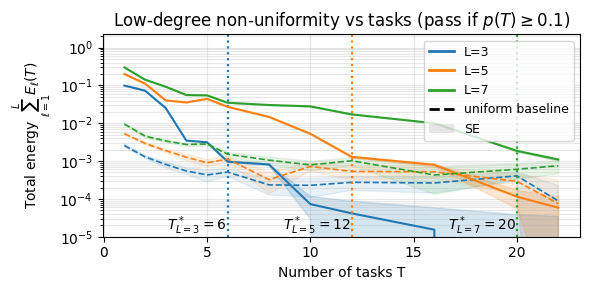

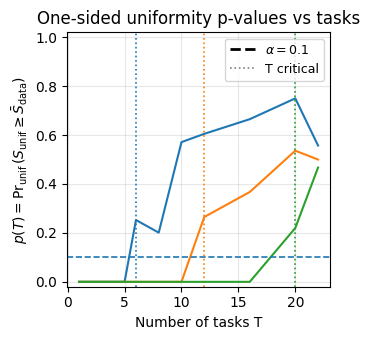

In [7]:
# ----------------------------
# Plot: mean ± SE for data and uniform baseline
# ----------------------------
def plot_total_energy_sd_with_pvals(
    Ts,
    stats,
    baseline,
    pvals,
    Tcrit,
    L_max_list=(5,10,20),
    alpha=0.1,
    logy=True,
    title="Low-degree non-uniformity vs tasks (mean±SE)",
):
    Ts = np.asarray(Ts)
    plt.figure(figsize=(6, 3))
    colors = cm.tab10.colors
    for iL, L in enumerate(L_max_list):
        mean = stats[L]["mean"]
        sd   = stats[L]["sd"]
        se  = stats[L]["se"]

        bmean = baseline[L]["mean"]
        bsd   = baseline[L]["sd"]
        bse   = baseline[L]["se"]

        # Data mean ± SE
        plt.plot(Ts, mean, label=rf"data: $\sum_{{\ell=1}}^{{{L}}}E_\ell$", c=colors[iL % len(colors)])
        plt.fill_between(
            Ts,
            np.maximum(mean - se, 1e-18),
            np.maximum(mean + se, 1e-18),
            alpha=0.18,
            color=colors[iL % len(colors)]
        )

        # Baseline mean ± SE
        plt.plot(
            Ts, bmean, linestyle="--", linewidth=1.2,
            label=rf"uniform: $\sum_{{\ell=1}}^{{{L}}}E_\ell$", 
            c=colors[iL % len(colors)]
        )
        plt.fill_between(
            Ts,
            np.maximum(bmean - bse, 1e-18),
            np.maximum(bmean + bse, 1e-18),
            alpha=0.10,
            color=colors[iL % len(colors)]
        )

        # Vertical line at first T that passes p(T) >= alpha
        tc = Tcrit[L]
        if tc is not None:
            plt.axvline(tc, linestyle=":", linewidth=1.6, color=colors[iL % len(colors)])
            # annotate near top of plot region
            # y_annot = max(1e-18, np.max(mean + se)) * 0.9
            y_annot = 10**-5
            plt.text(tc-0.05, y_annot, rf"$T^*_{{L={L}}}={tc}$", rotation=0, va="bottom", ha="right")

    if logy:
        plt.yscale("log")
    plt.xlabel("Number of tasks T")
    plt.ylabel(r"Total energy $\sum_{\ell=1}^{L} E_\ell(T)$")
    plt.title(title + rf" (pass if $p(T)\geq {alpha}$)")
    plt.grid(True, which="both", alpha=0.3)
    #manual legend with solid line colors for each L
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    handles = [
        Line2D([0], [0], color=colors[iL % len(colors)], lw=2, label=rf"L={L}")
        for iL, L in enumerate(L_max_list)
    ]
    #add dashed line in black for baseline
    handles.append(Line2D([0], [0], color="black", lw=2, linestyle="--", label="uniform baseline"))
    #add shaded alpha patch for SE
    handles.append(Patch(facecolor="gray", edgecolor="none", alpha=0.18, label="SE"))
    plt.legend(handles=handles, fontsize=9)
    
    plt.ylim(10**-5, None)
    plt.tight_layout()
    plt.show()

    # Optional: also plot p-values
    plt.figure(figsize=(3.5, 3.5))
    for iL, L in enumerate(L_max_list):
        plt.plot(Ts, pvals[L], label=rf"$L={L}$")
        tc = Tcrit[L]
        if tc is not None:
            plt.axvline(tc, linestyle=":", linewidth=1.2, color=colors[iL % len(colors)])
    plt.axhline(alpha, linestyle="--", linewidth=1.2)
    plt.ylim(-0.02, 1.02)
    plt.xlabel("Number of tasks T")
    plt.ylabel(r"$p(T)=\Pr_{\rm unif}(S_{\rm unif}\geq \bar S_{\rm data})$")
    plt.title("One-sided uniformity p-values vs tasks")
    plt.grid(True, alpha=0.3)
    # plt.legend()
    handles = []
    # handles = [
    #     Line2D([0], [0], color=colors[iL % len(colors)], lw=2, label=rf"L={L}")
    #     for iL, L in enumerate(L_max_list)
    # ]
    #add dashed line in black for baseline
    handles.append(Line2D([0], [0], color="black", lw=2, linestyle="--", label=rf"$\alpha = {alpha}$"))
    handles.append(Line2D([0], [0], color="gray", lw=1.2, linestyle=":", label="T critical"))
    plt.legend(handles=handles, fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
plot_total_energy_sd_with_pvals(
    Ts=Ts,
    stats=stats,
    baseline=baseline,
    pvals=pvals,
    Tcrit=Tcrit,
    L_max_list=L_max_list,
    alpha=alpha,
    logy=True,
    title="Low-degree non-uniformity vs tasks",
)

Now we would like to visualize the eigenspectrum decay of the NTKs under uniform sampling to estimate the decay laws we should expect for the uniform subsets of our multitask eigenspectrums. To begin we start with the analytical expressions for the NTK eigenvalues in terms of Gegenbauer polynomials $C_\ell^{(\alpha)}$.

\begin{equation}
\mu^{\mathrm{bias}}_\ell
=
\frac{\omega_{p-1}}{\omega_{p-2}}\,
\frac{1}{C_\ell^{(\alpha)}(1)}
\int_{-1}^1
\left[
\sigma_v^2\,\frac{\pi-\arccos(\rho(t))}{2\pi}
\right]
C_\ell^{(\alpha)}(t)\,(1-t^2)^{\alpha-\frac12}\,dt.
\end{equation}

\begin{equation}
\mu^{\mathrm{NTK}}_\ell
=
\frac{\omega_{p-1}}{\omega_{p-2}}\,
\frac{1}{C_\ell^{(\alpha)}(1)}
\int_{-1}^1
\left[
\frac{q}{2\pi}\Big(\sin\theta(t)+(\pi-\theta(t))\cos\theta(t)\Big)
+
\sigma_v^2\,(t+1)\,\frac{\pi-\theta(t)}{2\pi}
\right]
C_\ell^{(\alpha)}(t)\,(1-t^2)^{\alpha-\frac12}\,dt.
\end{equation}

The simplified integral form we need to solve numericaly is:

\begin{equation}
I_\ell
=
\int_{-1}^1
\underbrace{\kappa(t)\,C_\ell^{(\alpha)}(t)}_{f(t)}\,(1-t^2)^{\alpha-\frac12}\,dt.
\end{equation}

Rewrite the weight as:
\begin{equation}
(1-t^2)^{\alpha-\frac12}
=(1-t^2)^{a}\,(1-t^2)^{b}
\end{equation}
where $a=b=\alpha - \frac12$. The Gauss-Jacobi (in our case Gauss-Gegenbauer), quadrature gives nodes $\{t_i\}$ and weights $\{w_i\}$ such that:
\begin{equation}
\int_{-1}^1 f(t)\,(1-t^2)^{a}\,(1-t^2)^{b}\,dt
\approx
\sum_{i=1}^n w_i\,f(t_i).
\end{equation}
and this approximation is exact for polynomials of degree up to $2n-1$. This is the numerical method we will use to compute the integrals for the NTK eigenvalues.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from multiTasking.utils.utils import KernelParams, _relu_kappa_components_sphere

from scipy import special

# -----------------------------
# Geometry helpers
# -----------------------------
def sphere_surface_area(d: int) -> float:
    # ω_d = 2 π^{(d+1)/2} / Γ((d+1)/2)
    return 2.0 * np.pi ** ((d + 1) / 2.0) / special.gamma((d + 1) / 2.0)

def omega_ratio(p: int) -> float:
    return sphere_surface_area(p - 1) / sphere_surface_area(p - 2)


# -----------------------------
# ReLU kernel pieces (biased) on sphere
# -----------------------------
def kappa_bias_only(t: np.ndarray, par: KernelParams) -> np.ndarray:
    _, k1 = _relu_kappa_components_sphere(t, par)
    return par.sigma_v2 * k1 + par.sigma_bout2

def kappa_full_ntk(t: np.ndarray, par: KernelParams) -> np.ndarray:
    k0, k1 = _relu_kappa_components_sphere(t, par)
    return k0 + par.sigma_v2 * (t + 1.0) * k1 + par.sigma_bout2

# -----------------------------
# Colleague-style kappa(t) probing from neural-tangents kernel_fn (S^2 only)
# -----------------------------
def xt_from_t_s2(t: float) -> np.ndarray:
    """
    Return a point on S^2 with dot(x0, xt) = t, where x0 = (0,0,1).
    """
    t = float(np.clip(t, -1.0, 1.0))
    return np.array([[np.sqrt(max(0.0, 1.0 - t*t)), 0.0, t]], dtype=np.float64)

def kappa_from_kernel_fn(t: float, kernel_fn) -> float:
    """
    Evaluate isotropic kernel kappa(t) by probing kernel_fn(x0, xt, 'ntk') on S^2.
    kernel_fn is assumed to accept numpy/jax arrays; we pass numpy.
    """
    x0 = np.array([[0.0, 0.0, 1.0]], dtype=np.float64)
    xt = xt_from_t_s2(t)
    val = kernel_fn(x0, xt, "ntk")
    # kernel_fn might return numpy, jax DeviceArray, or pytree; handle scalar [0,0]
    val = np.asarray(val)
    return float(val[0, 0])

def mercer_lambda_legendre_quad(l: int, kernel_fn, epsabs=1e-8, epsrel=1e-8) -> float:
    """
    Colleague method for S^2: lambda_l = 2π ∫_{-1}^1 kappa(t) P_l(t) dt.
    """
    Pl = lambda t: special.eval_legendre(l, t)
    integrand = lambda t: kappa_from_kernel_fn(t, kernel_fn) * Pl(t)
    val, _ = quad(integrand, -1.0, 1.0, epsabs=epsabs, epsrel=epsrel, limit=200)
    return float(2.0 * np.pi * val)

def compute_spectrum_colleague(
    Lmax: int,
    kernel_fn,
    epsabs=1e-8,
    epsrel=1e-8,
) -> np.ndarray:
    """
    Degree spectrum via colleague method (S^2 only).
    Returns lambdas[0..Lmax].
    """
    lam = np.zeros(Lmax + 1, dtype=float)
    for l in range(Lmax + 1):
        lam[l] = mercer_lambda_legendre_quad(l, kernel_fn, epsabs=epsabs, epsrel=epsrel)
        print(f"l={l}: lambda_colleague={lam[l]:.6g}")
    return lam

# -----------------------------
# Kernel ratio diagnostic
# -----------------------------
def kernel_ratio_grid(
    kappa_analytic_fn,
    par: KernelParams,
    kernel_fn,
    n_grid: int = 401,
    clip: float = 1e-14,
):
    """
    Evaluate kappa_nt(t)/kappa_analytic(t) on a t-grid.
    """
    ts = np.linspace(-1.0, 1.0, n_grid)
    k_ana = np.asarray(kappa_analytic_fn(ts, par), dtype=float)
    k_nt = np.array([kappa_from_kernel_fn(t, kernel_fn) for t in ts], dtype=float)

    denom = np.where(np.abs(k_ana) < clip, np.sign(k_ana) * clip + (k_ana == 0) * clip, k_ana)
    ratio = k_nt / denom
    return ts, k_nt, k_ana, ratio

def best_global_scale(a: np.ndarray, b: np.ndarray, mask=None) -> float:
    """
    Find scalar s minimizing ||s*a - b||_2 over masked entries.
    Useful to align colleague eigenvalues to analytic ones when only a scale differs.
    """
    if mask is None:
        mask = np.ones_like(a, dtype=bool)
    aa = a[mask]
    bb = b[mask]
    denom = float(np.dot(aa, aa))
    if denom <= 0:
        return 1.0
    return float(np.dot(aa, bb) / denom)



# -----------------------------
# Funk–Hecke via Gauss–Jacobi quadrature
# -----------------------------
#check convergence
def mu_convergence(l, kappa_fn, par, n1=300, n2=600):
    m1 = mu_ell_via_jacobi(l, kappa_fn, par, n_quad=n1)
    m2 = mu_ell_via_jacobi(l, kappa_fn, par, n_quad=n2)
    rel = abs(m2 - m1) / max(abs(m2), 1e-14)
    return m1, m2, rel

def mu_ell_via_jacobi(l: int, kappa_fn, par: KernelParams, n_quad: int = 500, p: int = 3) -> float:
    alpha = (p - 2) / 2.0
    a = alpha - 0.5  # (p-3)/2
    b = alpha - 0.5

    # nodes/weights for ∫_{-1}^1 f(t) (1-t)^a (1+t)^b dt
    t_nodes, w_nodes = special.roots_jacobi(n_quad, a, b)

    C_l = special.eval_gegenbauer(l, alpha, t_nodes)
    C_l_1 = float(special.eval_gegenbauer(l, alpha, 1.0))

    kap = kappa_fn(t_nodes, par)
    integral = float(np.sum(w_nodes * kap * C_l))

    return float(omega_ratio(p) * (integral / C_l_1))

def compute_spectrum(Lmax: int, kappa_fn, par: KernelParams, n_quad: int = 500, p: int = 3) -> np.ndarray:
    mus = np.zeros(Lmax + 1, dtype=float)
    for l in range(Lmax + 1):
        mus[l] = mu_ell_via_jacobi(l, kappa_fn, par, n_quad=n_quad, p=p)
        #check convergence
        m1, m2, rel = mu_convergence(l, kappa_fn, par, n1=n_quad, n2=n_quad*2)
        print(f"l={l}: mu(n={n_quad})={m1:.6g}, mu(n={n_quad*2})={m2:.6g}, rel diff={rel:.3g}")
    return mus

# -----------------------------
# Error-band computation
# -----------------------------
def spectrum_with_error_band(
    Lmax: int,
    kappa_fn,
    par: KernelParams,
    n_quad: int,
    use_center: str = "fine",   # "fine" uses 2n as center; "coarse" uses n as center
    eps: float = 1e-300,        # avoid zeros for semilogy fill clipping
    p: int = 3,                 # dimension for Funk–Hecke quadrature (S^{p-1} sphere
):
    """
    Returns:
      ells: degrees
      mu_center: chosen center curve (default: fine = n=2n)
      mu_lo, mu_hi: error band using |mu_fine - mu_coarse|
      mu_coarse, mu_fine: raw curves (n and 2n)
    """
    mu_coarse = compute_spectrum(Lmax, kappa_fn, par, n_quad=n_quad, p=p)
    mu_fine = compute_spectrum(Lmax, kappa_fn, par, n_quad=2 * n_quad, p=p)

    err = abs(mu_fine - mu_coarse) / np.maximum(abs(mu_fine), 1e-14)

    if use_center == "fine":
        mu_center = mu_fine
    elif use_center == "coarse":
        mu_center = mu_coarse
    else:
        raise ValueError("use_center must be 'fine' or 'coarse'.")

    mu_lo = np.maximum(mu_center - err, eps)
    mu_hi = np.maximum(mu_center + err, eps)

    ells = np.arange(Lmax + 1, dtype=float)
    return ells, mu_center, mu_lo, mu_hi, mu_coarse, mu_fine, err



# -----------------------------
# Fit models (log-space least squares)
# -----------------------------
def _log_r2(y_true_log: np.ndarray, y_pred_log: np.ndarray) -> float:
    ss_res = np.sum((y_true_log - y_pred_log) ** 2)
    ss_tot = np.sum((y_true_log - np.mean(y_true_log)) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

def fit_powerlaw_log(mus: np.ndarray, ell_min: int, ell_max: int):
    """
    Fit mu ≈ C * ell^{-s} via log(mu)=log C - s log ell   (ell>=1)
    Returns C, s, R2_log
    """
    ells = np.arange(len(mus), dtype=float)
    sel = (ells >= max(1, ell_min)) & (ells <= ell_max) & (mus > 0)
    x = np.log(ells[sel])
    y = np.log(mus[sel])

    slope, intercept = np.polyfit(x, y, 1)  # y = slope*x + intercept
    C = float(np.exp(intercept))
    s = float(-slope)

    yhat = intercept + slope * x
    r2 = float(_log_r2(y, yhat))
    return C, s, r2


# -----------------------------
# Bietti reference (power law with exponent p)
# -----------------------------
def bietti_reference_powerlaw(Lmax: int, p: int, mu_ref: float, ell_ref: int) -> np.ndarray:
    ells = np.arange(Lmax + 1, dtype=float)
    ref = np.full_like(ells, np.nan, dtype=float)  # NaN at ell=0 prevents spike/line

    mask = ells >= 1
    ref[mask] = ells[mask] ** (-p)

    # normalize at ell_ref
    if ell_ref < 1 or ell_ref > Lmax:
        raise ValueError("ell_ref must be between 1 and Lmax for Bietti reference.")
    scale = mu_ref / (ell_ref ** (-p))
    ref[mask] *= scale
    return ref


# -----------------------------
# Main
# -----------------------------
p = 3  # dimension for Funk–Hecke quadrature (S^{p-1} sphere)
par = KernelParams(sigma_w2=1.0, sigma_b2=0.2, sigma_v2=1.0, sigma_bout2=1.0)

Lmax = 60
n_quad = 700

# Choose a fit window you believe is in the asymptotic regime
fit_range = (1, Lmax)
# Compute spectra
mu_bias = compute_spectrum(Lmax, kappa_bias_only, par, n_quad=n_quad, p=p)
mu_full = compute_spectrum(Lmax, kappa_full_ntk, par, n_quad=n_quad, p=p)

_, _, lo_bias, hi_bias, _, _, err_bias = spectrum_with_error_band(
        Lmax, kappa_bias_only, par, n_quad=n_quad, use_center="fine"
    )
_, _, lo_full, hi_full, _, _, err_full = spectrum_with_error_band(
    Lmax, kappa_full_ntk, par, n_quad=n_quad, use_center="fine"
)

ells = np.arange(Lmax + 1, dtype=float)

C_b, s_b, r2pow_b = fit_powerlaw_log(mu_bias, *fit_range)
C_f, s_f, r2pow_f = fit_powerlaw_log(mu_full, *fit_range)

pow_fit_bias = np.full_like(ells, np.nan)
pow_fit_full = np.full_like(ells, np.nan)
mask = ells >= 1
pow_fit_bias[mask] = C_b * (ells[mask] ** (-s_b))
pow_fit_full[mask] = C_f * (ells[mask] ** (-s_f))

# Bietti reference: μ_ell ∝ ell^{-p}
ell_ref = 10
mu_ref = float(mu_full[ell_ref])
bietti = bietti_reference_powerlaw(Lmax, p=p, mu_ref=mu_ref, ell_ref=ell_ref)

l=0: mu(n=700)=5.12947, mu(n=1400)=5.12947, rel diff=0
l=1: mu(n=700)=0.201756, mu(n=1400)=0.201756, rel diff=0
l=2: mu(n=700)=0.0119522, mu(n=1400)=0.0119522, rel diff=4.68e-07
l=3: mu(n=700)=0.00878516, mu(n=1400)=0.00878516, rel diff=2.12e-07
l=4: mu(n=700)=0.00291941, mu(n=1400)=0.00291941, rel diff=1.04e-06
l=5: mu(n=700)=0.00188775, mu(n=1400)=0.00188775, rel diff=2.47e-07
l=6: mu(n=700)=0.00104604, mu(n=1400)=0.00104603, rel diff=1.02e-05
l=7: mu(n=700)=0.000706258, mu(n=1400)=0.000706258, rel diff=0
l=8: mu(n=700)=0.000474764, mu(n=1400)=0.00047478, rel diff=3.33e-05
l=9: mu(n=700)=0.000342454, mu(n=1400)=0.00034246, rel diff=1.9e-05
l=10: mu(n=700)=0.000252247, mu(n=1400)=0.000252253, rel diff=2.58e-05
l=11: mu(n=700)=0.000192154, mu(n=1400)=0.000192173, rel diff=9.69e-05
l=12: mu(n=700)=0.000149384, mu(n=1400)=0.000149392, rel diff=4.99e-05
l=13: mu(n=700)=0.000118557, mu(n=1400)=0.000118569, rel diff=9.43e-05
l=14: mu(n=700)=9.56282e-05, mu(n=1400)=9.56059e-05, rel diff=0.00

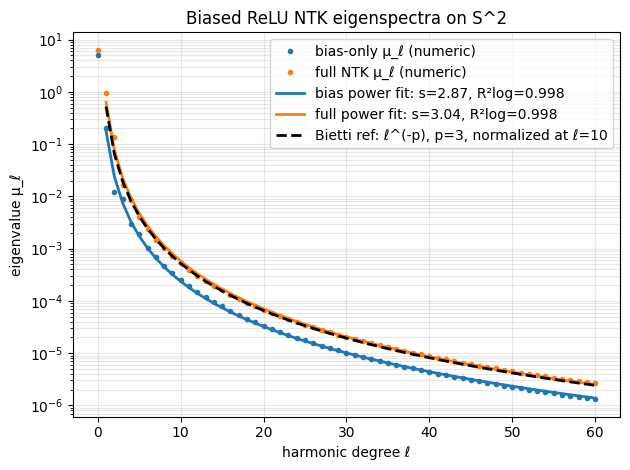

Fit range: (1, 60)
Bias pow:  C=0.176, s=2.87, R2_log=0.998
Full pow:  C=0.636, s=3.04, R2_log=0.998


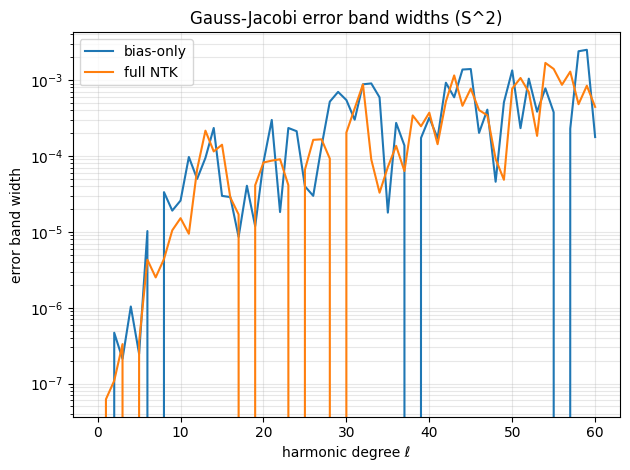

In [4]:
# Plot (semilogy)
plt.figure()
# shaded error bands
# plt.fill_between(ells, lo_bias, hi_bias, alpha=0.2, label=f"bias-only quadrature band (n={n_quad} vs {2*n_quad})")
# plt.fill_between(ells, lo_full, hi_full, alpha=0.2, label=f"full NTK quadrature band (n={n_quad} vs {2*n_quad})")

# # center curves on top
# plt.semilogy(ells, mu_bias, "o-", markersize=3, linewidth=1, label="bias-only μ_ℓ (center = 2n)", c='tab:blue')
# plt.semilogy(ells, mu_full, "o-", markersize=3, linewidth=1, label="full NTK μ_ℓ (center = 2n)", c='tab:orange')

plt.semilogy(ells, mu_bias, "o", markersize=3, label="bias-only μ_ℓ (numeric)", c='tab:blue')
plt.semilogy(ells, mu_full, "o", markersize=3, label="full NTK μ_ℓ (numeric)", c='tab:orange')

# Power-law fits (often the right shape for NTK)
plt.semilogy(ells, pow_fit_bias, linewidth=2,
                label=f"bias power fit: s={s_b:.3g}, R²log={r2pow_b:.3f}",color='tab:blue')
plt.semilogy(ells, pow_fit_full, linewidth=2,
                label=f"full power fit: s={s_f:.3g}, R²log={r2pow_f:.3f}",color='tab:orange')

# Bietti reference
plt.semilogy(ells, bietti, "k--", linewidth=2,
                label=f"Bietti ref: ℓ^(-p), p={p}, normalized at ℓ={ell_ref}")

plt.xlabel("harmonic degree ℓ")
plt.ylabel("eigenvalue μ_ℓ")
plt.title(f"Biased ReLU NTK eigenspectra on S^{p-1}")# (n_quad={n_quad})
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Fit range:", fit_range)
print(f"Bias pow:  C={C_b:.3g}, s={s_b:.3g}, R2_log={r2pow_b:.3f}")
print(f"Full pow:  C={C_f:.3g}, s={s_f:.3g}, R2_log={r2pow_f:.3f}")

#plot difference between lo and hi bands
plt.figure()
plt.semilogy(ells, err_bias, label="bias-only")
plt.semilogy(ells, err_full, label="full NTK")
plt.xlabel("harmonic degree ℓ")
plt.ylabel("error band width")
plt.title(f"Gauss-Jacobi error band widths (S^{p-1})")# (n_quad={n_quad})")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

l=0: lambda_colleague=24.2196
l=1: lambda_colleague=1.37856
l=2: lambda_colleague=0.0942245
l=3: lambda_colleague=0.0202845
l=4: lambda_colleague=0.00853225
l=5: lambda_colleague=0.00442261
l=6: lambda_colleague=0.00260153
l=7: lambda_colleague=0.00166346
l=8: lambda_colleague=0.00112942
l=9: lambda_colleague=0.00080251
l=10: lambda_colleague=0.000590919
l=11: lambda_colleague=0.000447821
l=12: lambda_colleague=0.000347535
l=13: lambda_colleague=0.00027518
l=14: lambda_colleague=0.000221591
l=15: lambda_colleague=0.000181097
l=16: lambda_colleague=0.000149938
l=17: lambda_colleague=0.000125549
l=18: lambda_colleague=0.000106164
l=19: lambda_colleague=9.05601e-05
l=20: lambda_colleague=7.79264e-05
l=21: lambda_colleague=6.75091e-05
l=22: lambda_colleague=5.88397e-05
l=23: lambda_colleague=5.16309e-05
l=24: lambda_colleague=4.55325e-05
l=25: lambda_colleague=4.03645e-05
l=26: lambda_colleague=3.59598e-05
l=27: lambda_colleague=3.21593e-05
l=28: lambda_colleague=2.88813e-05
l=29: lambda_c

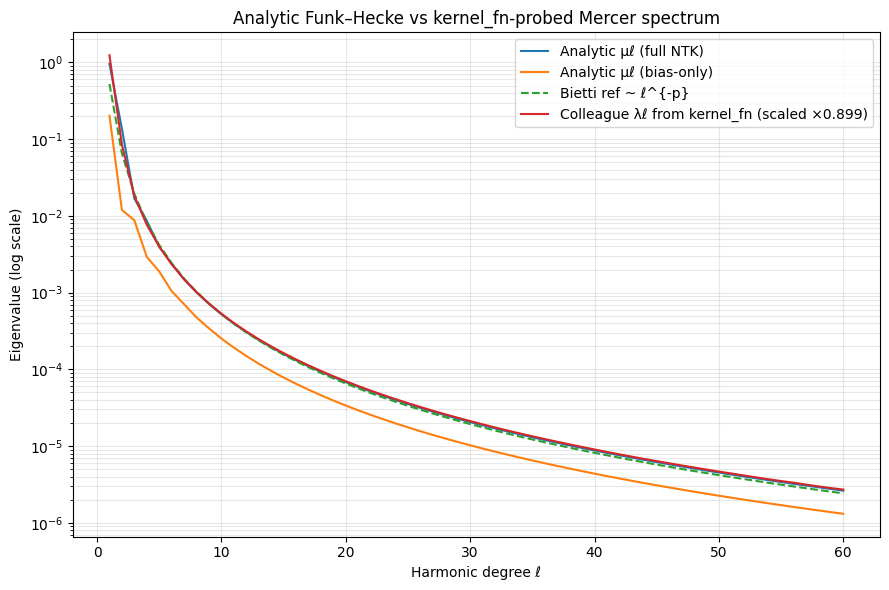

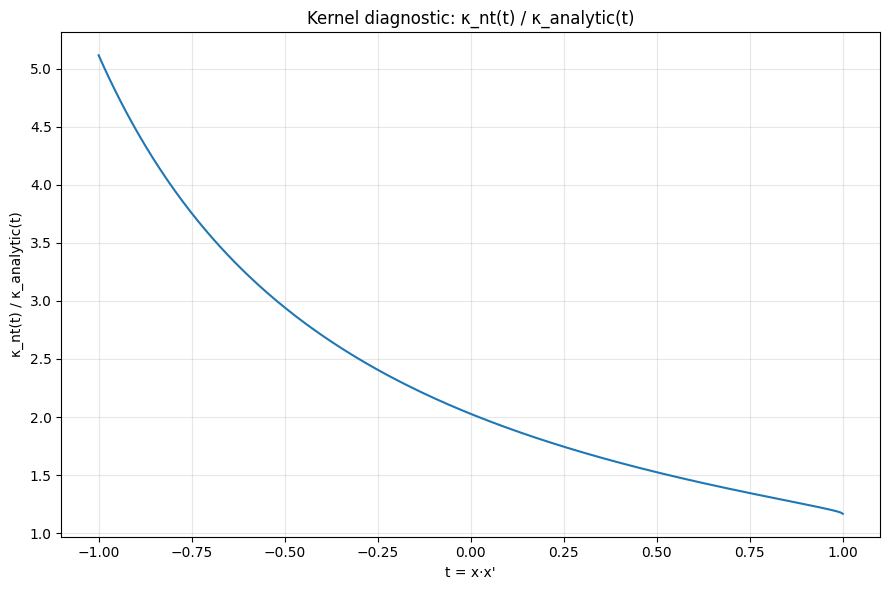

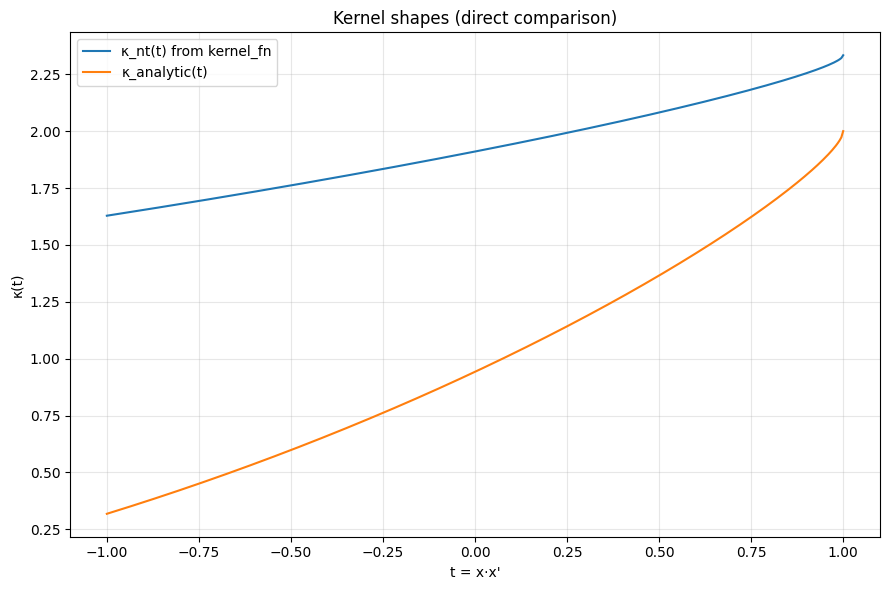

[-1.    -0.995 -0.99  -0.985 -0.98  -0.975 -0.97  -0.965 -0.96  -0.955
 -0.95  -0.945 -0.94  -0.935 -0.93  -0.925 -0.92  -0.915 -0.91  -0.905
 -0.9   -0.895 -0.89  -0.885 -0.88  -0.875 -0.87  -0.865 -0.86  -0.855
 -0.85  -0.845 -0.84  -0.835 -0.83  -0.825 -0.82  -0.815 -0.81  -0.805
 -0.8   -0.795 -0.79  -0.785 -0.78  -0.775 -0.77  -0.765 -0.76  -0.755
 -0.75  -0.745 -0.74  -0.735 -0.73  -0.725 -0.72  -0.715 -0.71  -0.705
 -0.7   -0.695 -0.69  -0.685 -0.68  -0.675 -0.67  -0.665 -0.66  -0.655
 -0.65  -0.645 -0.64  -0.635 -0.63  -0.625 -0.62  -0.615 -0.61  -0.605
 -0.6   -0.595 -0.59  -0.585 -0.58  -0.575 -0.57  -0.565 -0.56  -0.555
 -0.55  -0.545 -0.54  -0.535 -0.53  -0.525 -0.52  -0.515 -0.51  -0.505
 -0.5   -0.495 -0.49  -0.485 -0.48  -0.475 -0.47  -0.465 -0.46  -0.455
 -0.45  -0.445 -0.44  -0.435 -0.43  -0.425 -0.42  -0.415 -0.41  -0.405
 -0.4   -0.395 -0.39  -0.385 -0.38  -0.375 -0.37  -0.365 -0.36  -0.355
 -0.35  -0.345 -0.34  -0.335 -0.33  -0.325 -0.32  -0.315 -0.31  -0.305
 -0.3 

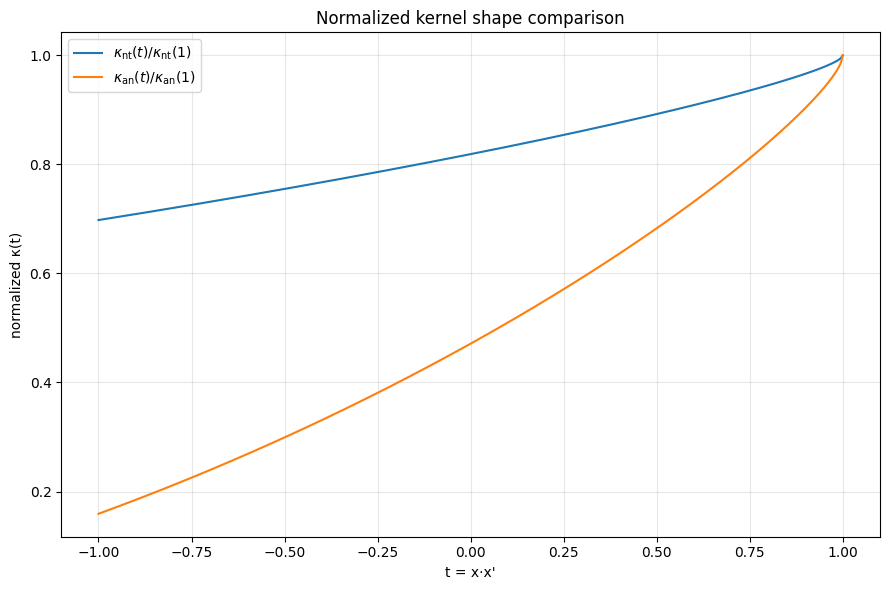

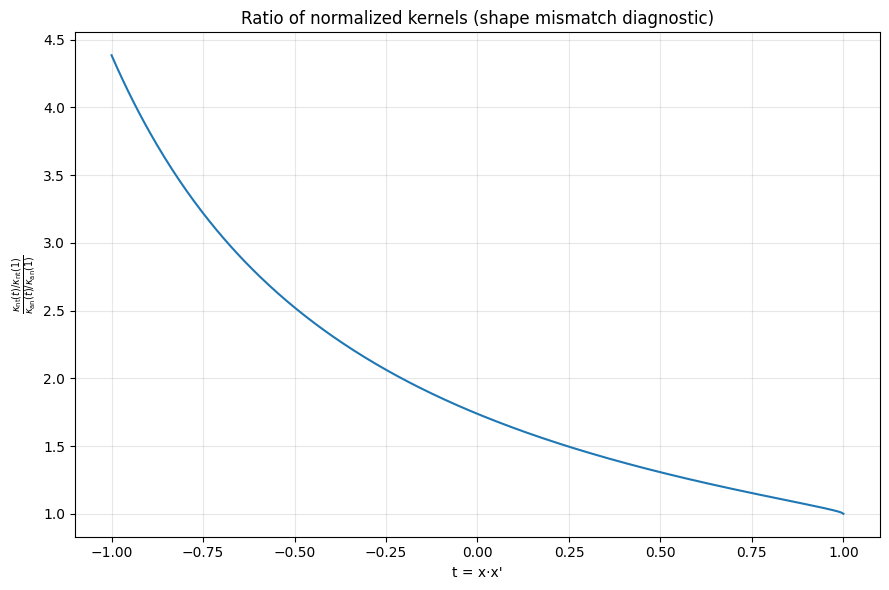

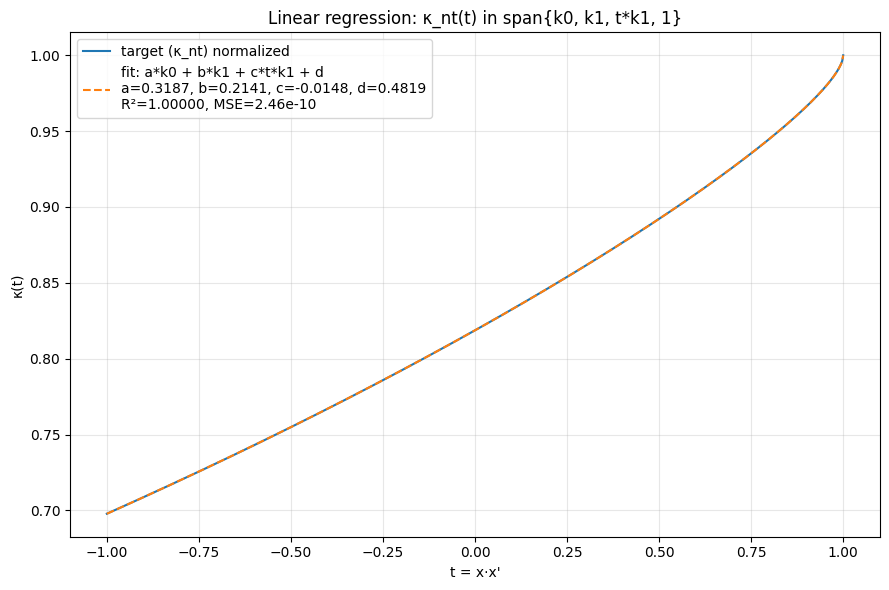

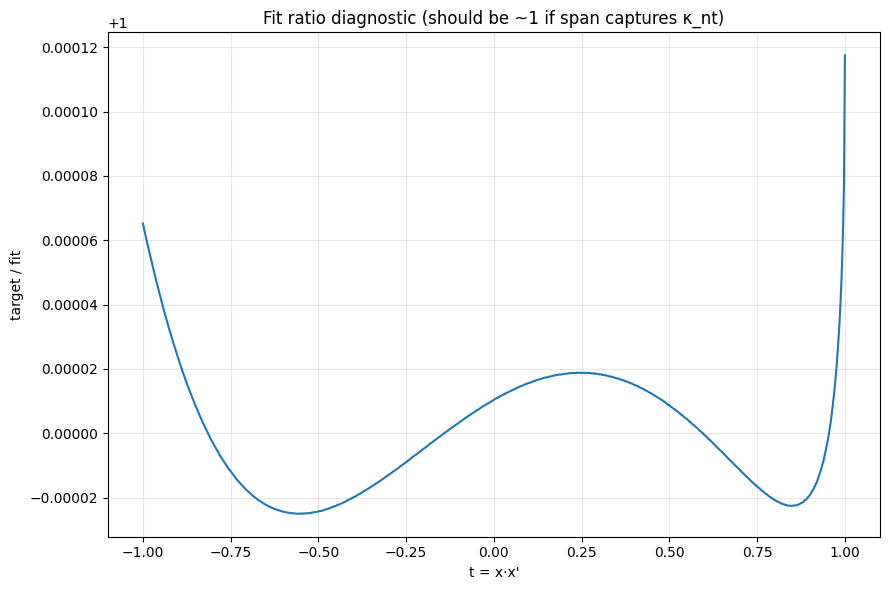

In [14]:
# -----------------------------
# Overlay: analytic spectrum vs colleague spectrum + Bietti
# -----------------------------
def plot_spectrum_overlay(
    ells: np.ndarray,
    mu_full: np.ndarray,
    mu_bias: np.ndarray,
    bietti: np.ndarray,
    lam_colleague: np.ndarray,
    scale_colleague: bool = True,
    scale_fit_range=(1, None),
    title="Mercer spectrum comparison (degree-sorted)",
):
    """
    Plot analytic mu_full/mu_bias, Bietti reference, and colleague-style lambdas.
    Optionally rescales colleague lambdas by a single global factor to best match mu_full.
    """
    Lmax = int(ells[-1])
    ell_min = max(1, int(scale_fit_range[0]))
    ell_max = Lmax if scale_fit_range[1] is None else int(scale_fit_range[1])

    mask = (ells >= ell_min) & (ells <= ell_max) & np.isfinite(mu_full) & np.isfinite(lam_colleague)
    # avoid ell=0 if you prefer (often special)
    mask = mask & (ells >= 1)

    lam_plot = lam_colleague.copy()
    s = 1.0
    if scale_colleague:
        s = best_global_scale(lam_colleague, mu_full, mask=mask)
        lam_plot = s * lam_plot

    plt.figure(figsize=(9, 6))
    plt.semilogy(ells[1:], mu_full[1:], label="Analytic μℓ (full NTK)")
    plt.semilogy(ells[1:], mu_bias[1:], label="Analytic μℓ (bias-only)")
    if np.any(np.isfinite(bietti[1:])):
        plt.semilogy(ells[1:], bietti[1:], "--", label="Bietti ref ~ ℓ^{-p}")
    plt.semilogy(ells[1:], lam_plot[1:], label=f"Colleague λℓ from kernel_fn (scaled ×{s:.3g})" if scale_colleague else "Colleague λℓ from kernel_fn")

    plt.xlabel("Harmonic degree ℓ")
    plt.ylabel("Eigenvalue (log scale)")
    plt.title(title)
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()

def plot_kernel_ratio(
    ts: np.ndarray,
    k_nt: np.ndarray,
    k_ana: np.ndarray,
    ratio: np.ndarray,
    title="Kernel diagnostic: κ_nt(t) / κ_analytic(t)",
):
    plt.figure(figsize=(9, 6))
    plt.plot(ts, ratio)
    plt.xlabel("t = x·x'")
    plt.ylabel("κ_nt(t) / κ_analytic(t)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.figure(figsize=(9, 6))
    plt.plot(ts, k_nt, label="κ_nt(t) from kernel_fn")
    plt.plot(ts, k_ana, label="κ_analytic(t)")
    plt.xlabel("t = x·x'")
    plt.ylabel("κ(t)")
    plt.title("Kernel shapes (direct comparison)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    
import numpy as np
from numpy.linalg import lstsq
import matplotlib.pyplot as plt

# ---- reuse your relu_kappa_components, kappa_full_ntk, etc. ----
# ---- plus reuse kappa_from_kernel_fn / xt_from_t_s2 from earlier ----

def kappa_nt_grid(kernel_fn, ts):
    return np.array([kappa_from_kernel_fn(float(t), kernel_fn) for t in ts], dtype=float)

def normalize_by_self_at_one(kvals, ts):
    # find nearest gridpoint to t=1
    idx1 = np.argmin(np.abs(ts - 1.0))
    k1 = kvals[idx1]
    return kvals / k1

def plot_normalized_kernel_comparison(kernel_fn, par, n_grid=401):
    ts = np.linspace(-1.0, 1.0, n_grid)

    # neural-tangents probed kernel
    k_nt = kappa_nt_grid(kernel_fn, ts)

    # your analytic kernel
    k_an = kappa_full_ntk(ts, par)

    # normalize both by their value at t=1
    k_nt_n = normalize_by_self_at_one(k_nt, ts)
    k_an_n = normalize_by_self_at_one(np.asarray(k_an, float), ts)

    # ratio of normalized shapes
    ratio_norm = k_nt_n / np.maximum(k_an_n, 1e-14)
    print(ts)
    print(ratio_norm)

    plt.figure(figsize=(9, 6))
    plt.plot(ts, k_nt_n, label=r"$\kappa_{\mathrm{nt}}(t)/\kappa_{\mathrm{nt}}(1)$")
    plt.plot(ts, k_an_n, label=r"$\kappa_{\mathrm{an}}(t)/\kappa_{\mathrm{an}}(1)$")
    plt.xlabel("t = x·x'")
    plt.ylabel("normalized κ(t)")
    plt.title("Normalized kernel shape comparison")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.figure(figsize=(9, 6))
    plt.plot(ts, ratio_norm)
    plt.xlabel("t = x·x'")
    plt.ylabel(r"$\frac{\kappa_{\mathrm{nt}}(t)/\kappa_{\mathrm{nt}}(1)}{\kappa_{\mathrm{an}}(t)/\kappa_{\mathrm{an}}(1)}$")
    plt.title("Ratio of normalized kernels (shape mismatch diagnostic)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    return ts, k_nt, k_an, k_nt_n, k_an_n, ratio_norm

def fit_nt_kernel_as_linear_combo(kernel_fn, par, n_grid=801, fit_on_normalized=True):
    ts = np.linspace(-1.0, 1.0, n_grid)

    # target: neural-tangents probed kernel
    y = kappa_nt_grid(kernel_fn, ts)

    # features from your analytic components
    k0, k1 = relu_kappa_components(ts, par)          # returns numpy arrays
    X = np.column_stack([
        np.asarray(k0, float),
        np.asarray(k1, float),
        np.asarray(ts, float) * np.asarray(k1, float),
        np.ones_like(ts, float),
    ])

    # optionally normalize (recommended) to focus on shape rather than global scale
    if fit_on_normalized:
        y = y / y[-1]  # since ts[-1] == 1
        X = X / X[-1, :]  # normalize each feature by its t=1 value (shape-only)

    # least squares fit
    coef, residuals, rank, svals = lstsq(X, y, rcond=None)
    yhat = X @ coef

    # metrics
    mse = float(np.mean((y - yhat)**2))
    denom = float(np.mean((y - np.mean(y))**2))
    r2 = float(1.0 - mse / denom) if denom > 0 else np.nan

    return {
        "ts": ts,
        "y": y,
        "yhat": yhat,
        "coef": coef,            # [a, b, c, d] in the chosen feature basis
        "mse": mse,
        "r2": r2,
        "fit_on_normalized": fit_on_normalized,
    }

def plot_linear_fit_result(res):
    ts = res["ts"]
    y = res["y"]
    yhat = res["yhat"]
    a, b, c, d = res["coef"]

    plt.figure(figsize=(9, 6))
    plt.plot(ts, y, label="target (κ_nt)" + (" normalized" if res["fit_on_normalized"] else ""))
    plt.plot(ts, yhat, "--", label=f"fit: a*k0 + b*k1 + c*t*k1 + d\n"
                                   f"a={a:.4g}, b={b:.4g}, c={c:.4g}, d={d:.4g}\n"
                                   f"R²={res['r2']:.5f}, MSE={res['mse']:.3g}")
    print(f"fit: a*k0 + b*k1 + c*t*k1 + d\n"
                                   f"a={a:.4g}, b={b:.4g}, c={c:.4g}, d={d:.4g}\n"
                                   f"R²={res['r2']:.5f}, MSE={res['mse']:.3g}")
    plt.xlabel("t = x·x'")
    plt.ylabel("κ(t)")
    plt.title("Linear regression: κ_nt(t) in span{k0, k1, t*k1, 1}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.figure(figsize=(9, 6))
    plt.plot(ts, y / np.maximum(yhat, 1e-14))
    plt.xlabel("t = x·x'")
    plt.ylabel("target / fit")
    plt.title("Fit ratio diagnostic (should be ~1 if span captures κ_nt)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



# Model creation
init_fn, apply_fn, kernel_fn = stax.serial(
    stax.Dense(512, W_std=1.0, b_std=1.0, parameterization="ntk"),
    stax.Relu(),
    stax.Dense(1, W_std=1.0, b_std=1.0, parameterization="ntk")
)

# Compute kernels
kernel_fn = nt.batch(kernel_fn, device_count=-1)

# Safety: colleague method assumes S^2 / p=3
if par.p != 3:
    raise ValueError("Colleague Legendre/quad method here is implemented for p=3 (S^2) only.")

# Compute colleague spectrum from kernel_fn
lam_colleague = compute_spectrum_colleague(Lmax, kernel_fn, epsabs=1e-8, epsrel=1e-8)

# Plot overlay (optionally scale colleague curve to align)
plot_spectrum_overlay(
    ells=ells,
    mu_full=mu_full,
    mu_bias=mu_bias,
    bietti=bietti,
    lam_colleague=lam_colleague,
    scale_colleague=True,
    scale_fit_range=(5, Lmax),   # fit scaling on mid/high ℓ to avoid low-ℓ quirks
    title="Analytic Funk–Hecke vs kernel_fn-probed Mercer spectrum",
)

# Kernel ratio diagnostic
ts, k_nt, k_ana, ratio = kernel_ratio_grid(
    kappa_analytic_fn=kappa_full_ntk,
    par=par,
    kernel_fn=kernel_fn,
    n_grid=401,
    clip=1e-14,
)
plot_kernel_ratio(ts, k_nt, k_ana, ratio)

plt.show()

par = KernelParams(p=3, sigma_w2=1.0**2, sigma_b2=1.0**2, sigma_v2=1.0)  # sigma_v2 may need matching

# 1) normalized kernel shape comparison
_ = plot_normalized_kernel_comparison(kernel_fn, par, n_grid=401)

# 2) linear regression reverse engineering
res = fit_nt_kernel_as_linear_combo(kernel_fn, par, n_grid=801, fit_on_normalized=True)
plot_linear_fit_result(res)

plt.show()

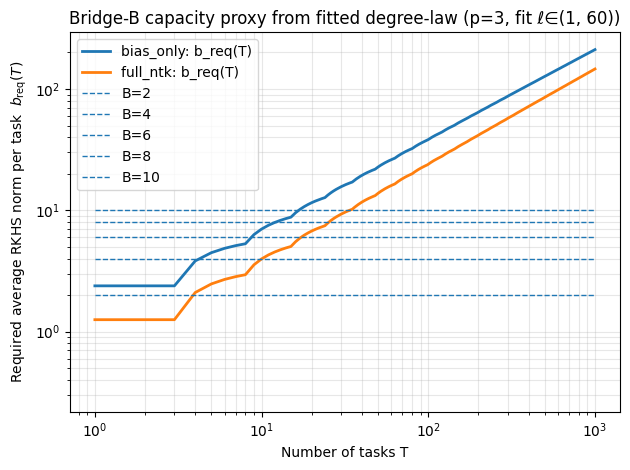

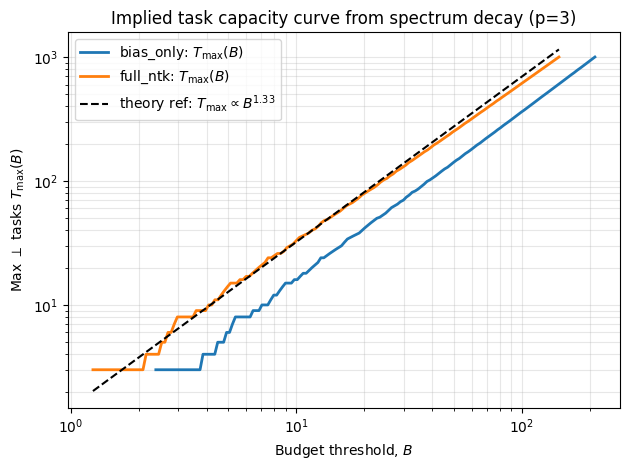


B=2
  bias_only: T_max ≈ 1
  full_ntk: T_max ≈ 3

B=4
  bias_only: T_max ≈ 4
  full_ntk: T_max ≈ 10

B=6
  bias_only: T_max ≈ 8
  full_ntk: T_max ≈ 17

B=8
  bias_only: T_max ≈ 12
  full_ntk: T_max ≈ 25

B=10
  bias_only: T_max ≈ 16
  full_ntk: T_max ≈ 33


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

# ----------------------------
# Inputs from your fits
# ----------------------------
p = 3  # sphere is S^{p-1}. For S^2, p=3.
fit_range = (1, 60)

fits = {
    "bias_only": {"C": 0.176, "s": 2.87},
    "full_ntk":  {"C": 0.636, "s": 3.04},
}

# ----------------------------
# Multiplicity of degree-l spherical harmonics on S^{p-1}
# d_l = dim(H_l(S^{p-1}))
# General closed form:
# d_l = (2l + p - 2) * (l + p - 3)! / (l! * (p - 2)!)
#
# For p=3 (S^2): d_l = 2l + 1
# ----------------------------
def harmonic_multiplicity(l: int, p: int) -> int:
    if l < 0:
        return 0
    if p < 2:
        raise ValueError("p must be >= 2.")
    if p == 2:
        # S^1: degree l has multiplicity 2 for l>=1, and 1 for l=0
        return 1 if l == 0 else 2
    # use integer arithmetic via combinations/factorials
    # d_l = (2l+p-2) * C(l+p-3, p-3) / (p-2)
    # equivalent but more stable as factorial ratio:
    # d_l = (2l+p-2) * (l+p-3)! / (l! (p-2)!)
    # We'll compute with comb:
    return (2*l + p - 2) * comb(l + p - 3, p - 3) // (p - 2)

# sanity check for p=3 -> 2l+1
if p == 3:
    for l in [0, 1, 2, 5, 10]:
        assert harmonic_multiplicity(l, 3) == 2*l + 1

# ----------------------------
# Build an approximate sorted-index spectrum mu_j from degree-law mu_l
# by repeating mu_l with multiplicity d_l.
#
# Important: the l=0 mode is special; for the Bridge-B scaling and your fit,
# we typically start at l=1. We'll omit l=0 here by default.
# ----------------------------
def build_mu_j_from_degree_law(C: float, s: float, p: int, Lmax: int, include_l0: bool = False) -> np.ndarray:
    mu_list = []
    l_start = 0 if include_l0 else 1
    for l in range(l_start, Lmax + 1):
        mu_l = C * (l ** (-s)) if l > 0 else np.nan  # l=0 not defined in this law
        d_l = harmonic_multiplicity(l, p)
        mu_list.extend([mu_l] * d_l)
    mu_j = np.array(mu_list, dtype=float)
    # remove nan if include_l0 accidentally left it
    mu_j = mu_j[np.isfinite(mu_j)]
    return mu_j

# ----------------------------
# Compute b_req(T): average required RKHS norm per task
# b_req^2(T) = (1/T) * sum_{j=1..T} 1/mu_j
# ----------------------------
def b_req_from_mu_j(mu_j: np.ndarray, Tmax: int) -> tuple[np.ndarray, np.ndarray]:
    mu_j = mu_j[:Tmax]
    inv_mu = 1.0 / mu_j
    prefix = np.cumsum(inv_mu)
    T = np.arange(1, len(mu_j) + 1)
    b2_req = prefix / T
    b_req = np.sqrt(b2_req)
    return T, b_req

# ----------------------------
# Invert b_req(T) to get T_max(B)
# ----------------------------
def Tmax_from_breq(T: np.ndarray, b_req: np.ndarray, B_grid: np.ndarray) -> np.ndarray:
    # b_req is increasing in T in this setting; use searchsorted on b_req
    # For each B, find largest T with b_req(T) <= B.
    idx = np.searchsorted(b_req, B_grid, side="right") - 1
    idx = np.clip(idx, 0, len(T) - 1)
    return T[idx]

# ----------------------------
# Build and plot
# ----------------------------
Lmax_for_expansion = 2000  # enough to get long mu_j lists; adjust if needed

# choose how many tasks you want to visualize in b_req(T)
T_plot_max = 1000

curves = {}
for name, fs in fits.items():
    mu_j = build_mu_j_from_degree_law(fs["C"], fs["s"], p=p, Lmax=Lmax_for_expansion, include_l0=False)
    if len(mu_j) < T_plot_max:
        raise ValueError(f"Need larger Lmax_for_expansion; got only {len(mu_j)} eigenvalues.")
    T, b_req = b_req_from_mu_j(mu_j, Tmax=T_plot_max)
    curves[name] = {"T": T, "b_req": b_req, "mu_j": mu_j}

# ---- Plot 1: b_req(T) ----
plt.figure()
for name, obj in curves.items():
    plt.loglog(obj["T"], obj["b_req"], linewidth=2, label=f"{name}: b_req(T)")

# Add a few illustrative budget thresholds B (edit as you like)
B_levels = [2, 4, 6, 8, 10]
for B in B_levels:
    plt.hlines(B, xmin=1, xmax=T_plot_max, linestyles="--", linewidth=1, label=f"B={B}")

plt.xlabel("Number of tasks T")
plt.ylabel(r"Required average RKHS norm per task  $b_{\mathrm{req}}(T)$")
plt.title(f"Bridge-B capacity proxy from fitted degree-law (p={p}, fit ℓ∈{fit_range})")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ---- Plot 2: Tmax(B) ----
# Choose a grid of B values spanning the plotted b_req range
# ---- Plot 2: Tmax(B) ----
plt.figure()

for name, obj in curves.items():
    bmin = float(obj["b_req"][0])
    bmax = float(obj["b_req"][-1])
    B_grid = np.logspace(np.log10(max(1e-6, bmin)), np.log10(bmax), 150)
    Tmax_grid = Tmax_from_breq(obj["T"], obj["b_req"], B_grid)

    plt.loglog(B_grid, Tmax_grid, linewidth=2, label=f"{name}: $T_{{\\max}}(B)$")

# ---- Theoretical reference scaling ----
# exponent = 2(p-1)/p  (from μ_ℓ ~ ℓ^{-p})
theory_exp = 2 * (p - 1) / p  # for p=3 → 4/3

# Use same B range as first curve for visual consistency
B_ref = np.logspace(np.log10(bmin), np.log10(bmax), 200)

# Normalize reference to roughly match magnitude at midpoint
B_mid = B_ref[len(B_ref)//2]
T_mid = Tmax_from_breq(
    curves["full_ntk"]["T"],
    curves["full_ntk"]["b_req"],
    np.array([B_mid])
)[0]

C_ref = T_mid / (B_mid ** theory_exp)
T_ref = C_ref * (B_ref ** theory_exp)

plt.loglog(
    B_ref,
    T_ref,
    "k--",
    linewidth=1.5,
    label=rf"theory ref: $T_{{\max}}\propto B^{{{theory_exp:.2f}}}$"
)

plt.xlabel("Budget threshold, $B$")
plt.ylabel(r"Max $\perp$ tasks $T_{\max}(B)$")
plt.title(f"Implied task capacity curve from spectrum decay (p={p})")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ---- Optional: print a few concrete Tmax numbers for your chosen B levels
for B in B_levels:
    print(f"\nB={B}")
    for name, obj in curves.items():
        # compute Tmax at exactly this B
        Tmax_val = Tmax_from_breq(obj["T"], obj["b_req"], np.array([B], dtype=float))[0]
        print(f"  {name}: T_max ≈ {int(Tmax_val)}")


In [8]:
# import numpy as np
# import jax.numpy as jnp
# import jax

# try:
#     import neural_tangents as nt
#     from neural_tangents import stax
# except Exception:
#     nt = None
#     stax = None


# # ----------------------------
# # Task sampling (same as yours)
# # ----------------------------
# def sample_random_normals_s2(K: int, rng: np.random.Generator) -> np.ndarray:
#     n = rng.normal(size=(K, 3))
#     n /= np.linalg.norm(n, axis=1, keepdims=True)
#     return n

# def normals_fibonacci_s2(K: int) -> np.ndarray:
#     ga = np.pi * (3.0 - np.sqrt(5.0))
#     i = np.arange(K, dtype=float)
#     z = 1.0 - 2.0*(i + 0.5)/K
#     r = np.sqrt(np.maximum(0.0, 1.0 - z*z))
#     phi = ga * i
#     x = r * np.cos(phi)
#     y = r * np.sin(phi)
#     return np.stack([x, y, z], axis=1)

# def generate_single_circle(normal, pts, m, phase_offset=0.0):
#     n = normal / np.linalg.norm(normal)
#     v1 = np.array([1., 0., 0.]) if abs(n[0]) < 0.9 else np.array([0., 1., 0.])
#     v1 = v1 - n * np.dot(n, v1)
#     v1 /= np.linalg.norm(v1)
#     v2 = np.cross(n, v1)

#     phi = np.linspace(0, 2*np.pi, pts, endpoint=False) + phase_offset
#     X = np.outer(np.cos(phi), v1) + np.outer(np.sin(phi), v2)
#     y = np.sin(m * phi)
#     return X, y

# def generate_multi_tasks_from_normals_phases(
#     normals: np.ndarray,
#     phases: np.ndarray,
#     pts_per_circle: int,
#     m: int,
# ):
#     X_list, y_list, task_slices = [], [], []
#     start = 0
#     for j in range(normals.shape[0]):
#         X, y = generate_single_circle(normals[j], pts_per_circle, m, phase_offset=float(phases[j]))
#         X_list.append(X)
#         y_list.append(y)
#         task_slices.append(slice(start, start + pts_per_circle))
#         start += pts_per_circle
#     return np.vstack(X_list), np.concatenate(y_list), task_slices


# # ----------------------------
# # Closed-form spherical kernels
# # ----------------------------
# class KernelParams:
#     def __init__(self, sigma_w2=1.0, sigma_b2=1.0, sigma_v2=1.0):
#         self.sigma_w2 = float(sigma_w2)
#         self.sigma_b2 = float(sigma_b2)
#         self.sigma_v2 = float(sigma_v2)

# def _relu_kappa_components_sphere(t: jnp.ndarray, par: KernelParams):
#     q = par.sigma_w2 + par.sigma_b2
#     c = par.sigma_w2 * t + par.sigma_b2
#     rho = jnp.clip(c / q, -1.0, 1.0)
#     theta = jnp.arccos(rho)
#     kappa1 = (jnp.pi - theta) / (2.0 * jnp.pi)
#     kappa0 = (q / (2.0 * jnp.pi)) * (jnp.sin(theta) + (jnp.pi - theta) * jnp.cos(theta))
#     return kappa0, kappa1

# def gram_from_kappa(Xa: jnp.ndarray, Xb: jnp.ndarray, par: KernelParams, which: str, kappa_scale: float = 1.0):
#     t = jnp.clip(Xa @ Xb.T, -1.0, 1.0)
#     k0, k1 = _relu_kappa_components_sphere(t, par)
#     if which == "full":
#         K = k0 + par.sigma_v2 * (t + 1.0) * k1
#     elif which == "bias":
#         K = par.sigma_v2 * k1
#     else:
#         raise ValueError("which must be 'full' or 'bias'")
#     return K * float(kappa_scale)

# def make_kappa_kernel_fn(par: KernelParams, which: str = "full", kappa_scale: float = 1.0):
#     """
#     Returns a function kernel_fn(X1, X2, get=...) suitable for nt.batch.
#     """
#     def kernel_fn(X1, X2, get="ntk", **kwargs):
#         K = gram_from_kappa(X1, X2, par=par, which=which, kappa_scale=kappa_scale)
#         if get in ("ntk", "nngp"):
#             return K
#         if isinstance(get, (tuple, list)):
#             return tuple(K for _ in get)
#         raise ValueError(f"Unsupported get={get}")
#     return kernel_fn


# # ----------------------------
# # neural-tangents backend
# # ----------------------------
# def gram_from_neural_tangents(Xa: jnp.ndarray, Xb: jnp.ndarray, which: str, W_std=1.0, b_std=1.0):
#     if nt is None:
#         raise ImportError("neural_tangents not available.")
#     if which == "full":
#         trainable = ("W", "b")
#     elif which == "bias":
#         trainable = ("b",)
#     else:
#         raise ValueError("which must be 'full' or 'bias'")

#     _, _, kernel_fn = stax.serial(
#         stax.Dense(1, W_std=W_std, b_std=b_std, parameterization="ntk", trainable=trainable),
#         stax.Relu(),
#         stax.Dense(1, W_std=W_std, b_std=b_std, parameterization="ntk", trainable=trainable),
#     )
#     kernel_fn = nt.batch(kernel_fn, device_count=-1)
#     return jnp.array(kernel_fn(Xa, Xb, "ntk"))

# def estimate_lambda_max(matvec, N, n_iter=20, key=0):
#     rng = np.random.default_rng(key)
#     v = jnp.array(rng.normal(size=(N,)), dtype=jnp.float32)
#     v = v / jnp.linalg.norm(v)

#     for _ in range(n_iter):
#         Kv = matvec(v)
#         v = Kv / jnp.linalg.norm(Kv)

#     return float(jnp.dot(v, matvec(v)))

# def top_eig_power_iteration(K: jnp.ndarray,
#                             n_iter: int = 50,
#                             tol: float = 1e-6,
#                             seed: int = 0):
#     """
#     Estimate largest eigenvalue of symmetric PSD K via power iteration.
#     Returns: (lambda_max_est, v)
#     """
#     assert K.ndim == 2 and K.shape[0] == K.shape[1]
#     n = K.shape[0]

#     key = jax.random.PRNGKey(seed)
#     v = jax.random.normal(key, (n,), dtype=K.dtype)
#     v = v / jnp.linalg.norm(v)

#     def body(state, _):
#         v, lam_old = state
#         w = K @ v
#         v_new = w / jnp.linalg.norm(w)
#         lam_new = jnp.vdot(v_new, K @ v_new).real  # Rayleigh quotient
#         return (v_new, lam_new), lam_new

#     # initialize lam_old = 0
#     (v_fin, lam_fin), lams = jax.lax.scan(body, (v, jnp.array(0., K.dtype)), None, length=n_iter)

#     # Optional: crude convergence check using last few Rayleigh quotients
#     # (keep it simple; you can also stop early with a while_loop)
#     return lam_fin, v_fin


# # ----------------------------
# # Unified runner with BOTH switches:
# #   - backend: "nt" vs "kappa"
# #   - generalization: "within" vs "across"
# # ----------------------------
# def _circle_basis_from_normal(normal: np.ndarray):
#     n = normal / np.linalg.norm(normal)
#     v1 = np.array([1., 0., 0.]) if abs(n[0]) < 0.9 else np.array([0., 1., 0.])
#     v1 = v1 - n * np.dot(n, v1)
#     v1 /= np.linalg.norm(v1)
#     v2 = np.cross(n, v1)
#     return n, v1, v2

# def generate_single_circle_with_phi(normal: np.ndarray, phi: np.ndarray, m: int):
#     """
#     normal: (3,)
#     phi: (pts,)
#     returns X: (pts,3), y: (pts,)
#     """
#     _, v1, v2 = _circle_basis_from_normal(normal)
#     X = np.outer(np.cos(phi), v1) + np.outer(np.sin(phi), v2)
#     y = np.sin(m * phi)
#     return X, y

# def generate_multi_tasks_from_normals_phases_with_mode(
#     normals: np.ndarray,
#     phases: np.ndarray,
#     pts_per_circle: int,
#     m: int,
#     rng: np.random.Generator,
#     mode: str = "grid",   # "grid" or "random"
# ):
#     X_list, y_list, task_slices = [], [], []
#     start = 0
#     for j in range(normals.shape[0]):
#         phase = float(phases[j])
#         if mode == "grid":
#             phi = np.linspace(0, 2*np.pi, pts_per_circle, endpoint=False) + phase
#         elif mode == "random":
#             phi = rng.uniform(0.0, 2*np.pi, size=pts_per_circle) + phase
#         else:
#             raise ValueError("mode must be 'grid' or 'random'")

#         X, y = generate_single_circle_with_phi(normals[j], phi, m)
#         X_list.append(X)
#         y_list.append(y)
#         task_slices.append(slice(start, start + pts_per_circle))
#         start += pts_per_circle
#     return np.vstack(X_list), np.concatenate(y_list), task_slices

# def run_kernel_multi_great_circle(
#     K_tasks: int,
#     pts_per_circle: int,
#     m: int,
#     seed: int,
#     reg_scale: float = 1e-5,
#     normals_mode: str = "random",
#     random_phase: bool = True,
#     generalization: str = "within",
#     backend: str = "kappa",
#     which: str = "full",
#     W_std: float = 1.0,
#     b_std: float = 1.0,
#     kappa_params=None,
#     kappa_scale: float = 1.0,
#     test_pts_per_circle: int | None = None,
#     # NEW: noise controls
#     snr: float | None = None,          # e.g. 1, 2, 5, 10, 20, ...
#     noise_std: float | None = None,    # overrides snr if provided
#     noise_on: str = "both",            # "train", "test", "both"
#     compute_spectrum: bool = False,
# ):
#     """
#     Returns per-task MSEs on TWO independent test replicates (A,B),
#     plus seed-level aggregates for baseline repeatability and model-baseline gap.

#     Baseline repeatability is estimated by comparing baseline MSE on test A vs test B.
#     Model-baseline gap is |MSE_model - MSE_base| / MSE_base on replicate A (and also B).
#     """
#     rng = np.random.default_rng(seed)
#     if test_pts_per_circle is None:
#         test_pts_per_circle = 2 * pts_per_circle

#     def sample_tasks(rng_local):
#         if normals_mode == "random":
#             normals = sample_random_normals_s2(K_tasks, rng=rng_local)
#         elif normals_mode == "fibonacci":
#             normals = normals_fibonacci_s2(K_tasks)
#         else:
#             raise ValueError("normals_mode must be 'random' or 'fibonacci'")
#         phases = rng_local.uniform(0, 2*np.pi, size=K_tasks) if random_phase else np.zeros(K_tasks)
#         return normals, phases

#     normals_tr, phases_tr = sample_tasks(rng)

#     if generalization == "within":
#         normals_te, phases_te = normals_tr, phases_tr
#     elif generalization == "across":
#         normals_te, phases_te = sample_tasks(rng)
#     else:
#         raise ValueError("generalization must be 'within' or 'across'")

#     # ----------------------------
#     # Train set: grid sampling
#     # ----------------------------
#     X_train_np, y_train_np, task_slices_train = generate_multi_tasks_from_normals_phases_with_mode(
#         normals_tr, phases_tr, pts_per_circle=pts_per_circle, m=m, rng=rng, mode="grid"
#     )

#     # ----------------------------
#     # Test replicate A/B: independent random sampling of phi
#     # ----------------------------
#     rngA = np.random.default_rng(seed + 10_000_001)

#     X_testA_np, y_testA_np, task_slices_testA = generate_multi_tasks_from_normals_phases_with_mode(
#         normals_te, phases_te, pts_per_circle=test_pts_per_circle, m=m, rng=rngA, mode="random"
#     )
    
#     # ----------------------------
#     # Optional: additive Gaussian label noise (SNR control)
#     # ----------------------------
#     # Signal variance for sin(m phi) is ~ 1/2 (exact for uniform phi).
#     # We estimate it empirically on the *noise-free* training labels.
#     if noise_std is None and snr is not None:
#         sig_var = float(np.var(y_train_np))  # empirical
#         noise_var = sig_var / float(snr)
#         noise_std = float(np.sqrt(max(noise_var, 0.0)))

#     if noise_std is not None and noise_std > 0:
#         rngN = np.random.default_rng(seed + 20_000_000)

#         if noise_on in ("train", "both"):
#             y_train_np = y_train_np + rngN.normal(0.0, noise_std, size=y_train_np.shape)

#         if noise_on in ("test", "both"):
#             # independent noise stream for test
#             rngNt = np.random.default_rng(seed + 30_000_000)
#             y_testA_np = y_testA_np + rngNt.normal(0.0, noise_std, size=y_testA_np.shape)

#     X_train = jnp.array(X_train_np, dtype=jnp.float32)
#     y_train = jnp.array(y_train_np, dtype=jnp.float32).reshape(-1, 1)

#     X_testA = jnp.array(X_testA_np, dtype=jnp.float32)
#     y_testA = jnp.array(y_testA_np, dtype=jnp.float32).reshape(-1, 1)

#     # ----------------------------
#     # Kernels
#     # ----------------------------
#     if backend == "nt":
#         K_train = gram_from_neural_tangents(X_train, X_train, which=which, W_std=W_std, b_std=b_std)
#         K_A_train = gram_from_neural_tangents(X_testA, X_train, which=which, W_std=W_std, b_std=b_std)

#     elif backend == "kappa":
#         if kappa_params is None:
#             kappa_params = KernelParams(sigma_w2=W_std**2, sigma_b2=b_std**2, sigma_v2=1.0)

#         kappa_kernel_fn = make_kappa_kernel_fn(kappa_params, which=which, kappa_scale=kappa_scale)
#         # batch for memory
#         if nt is None:
#             raise ImportError("neural_tangents not available for nt.batch; install neural_tangents or remove batching.")
#         kappa_kernel_fn = nt.batch(kappa_kernel_fn, device_count=-1)

#         K_train = jnp.array(kappa_kernel_fn(X_train, X_train, get="ntk"))
#         K_A_train = jnp.array(kappa_kernel_fn(X_testA, X_train, get="ntk"))
#     else:
#         raise ValueError("backend must be 'nt' or 'kappa'")

#     # ----------------------------
#     # Ridge solve with trace normalization (your existing convention)
#     # ----------------------------
#     # lam_max, _ = top_eig_power_iteration(jnp.asarray(K_train), n_iter=60, seed=0)
#     n = K_train.shape[0]
#     s_trace = jnp.trace(K_train) / n
#     K_tilde = K_train / s_trace
#     lam = reg_scale
#     # solve (K + eps*I) alpha = y_train
#     K_reg = K_tilde + (n*lam) * jnp.eye(n, dtype=K_train.dtype)
#     alpha = jnp.linalg.solve(K_reg, y_train)
#     if compute_spectrum:
#         eigvals = jnp.linalg.eigvalsh(K_train)

#     # Predictions on A/B
#     y_predA = K_A_train @ alpha

#     y_predA_np = np.asarray(y_predA).reshape(-1)
#     y_testA_np_flat = np.asarray(y_testA).reshape(-1)

#     # ----------------------------
#     # Per-task MSEs and baselines on both replicates
#     # ----------------------------
#     mse_model_A, mse_base_A = [], []
#     mse_model_B, mse_base_B = [], []

#     for sl_tr, sl_A in zip(task_slices_train, task_slices_testA):
#         # baseline constant fitted on TRAIN for that task
#         c = float(np.mean(y_train_np[sl_tr]))
#         # replicate A
#         ytA = y_testA_np_flat[sl_A]
#         ypA = y_predA_np[sl_A]
#         mse_model_A.append(float(np.mean((ytA - ypA) ** 2)))
#         mse_base_A.append(float(np.mean((ytA - c) ** 2)))

#     mse_model_A = np.array(mse_model_A)
#     mse_base_A  = np.array(mse_base_A)

#     # Seed-level aggregates (grand mean across tasks)
#     B_A = float(np.mean(mse_base_A))
#     M_A = float(np.mean(mse_model_A))


#     return dict(
#         mse_model_A=mse_model_A,
#         mse_base_A=mse_base_A,
#         # metadata
#         generalization=generalization,
#         backend=backend,
#         which=which,
#         eigvals=np.asarray(eigvals) if compute_spectrum else None,
#     )


# # ============================================================
# # Optional: one-shot calibration of kappa_scale to match NT
# # ============================================================

# def calibrate_kappa_scale(
#     X: np.ndarray,
#     backend_nt_kwargs: dict,
#     kappa_params: KernelParams,
#     which="full",
#     eps=1e-12,
# ):
#     """
#     Finds a scalar s such that s*K_kappa ≈ K_nt in least squares sense.
#     Useful because NTK parameterization conventions can differ by a constant factor.

#     Returns: scale s (float)
#     """
#     Xj = jnp.array(X, dtype=jnp.float32)

#     # NT Gram
#     K_nt = np.asarray(gram_from_neural_tangents(Xj, Xj, **backend_nt_kwargs, kind="ntk"))

#     # kappa Gram
#     K_k = np.asarray(gram_from_kappa(Xj, Xj, kappa_params, which=which))

#     # Solve for scalar s minimizing ||s K_k - K_nt||_F^2
#     num = float(np.sum(K_k * K_nt))
#     den = float(np.sum(K_k * K_k)) + eps
#     return num / den

# import numpy as np
# import matplotlib.pyplot as plt
# from tqdm.auto import tqdm


# # ----------------------------
# # Stats helpers (from earlier)
# # ----------------------------
# def paired_signflip_pvalue_one_sided(deltas: np.ndarray, n_perm: int = 5000, seed: int = 0) -> float:
#     """
#     Paired sign-flip test on deltas = (baseline - model).
#     H0: E[delta] <= 0   vs   H1: E[delta] > 0
#     """
#     rng = np.random.default_rng(seed)
#     deltas = np.asarray(deltas, dtype=float).reshape(-1)
#     obs = float(np.mean(deltas))

#     signs = rng.choice([-1.0, 1.0], size=(n_perm, deltas.size))
#     perm_means = (signs * deltas[None, :]).mean(axis=1)

#     p = (np.sum(perm_means >= obs) + 1.0) / (n_perm + 1.0)
#     return float(p)

# def benjamini_hochberg(pvals: np.ndarray) -> np.ndarray:
#     pvals = np.asarray(pvals, dtype=float)
#     m = pvals.size
#     order = np.argsort(pvals)
#     ranked = pvals[order]
#     q = ranked * m / (np.arange(1, m + 1))
#     q = np.minimum.accumulate(q[::-1])[::-1]
#     q = np.clip(q, 0.0, 1.0)
#     q_out = np.empty_like(q)
#     q_out[order] = q
#     return q_out


# # ----------------------------
# # Updated main sweep + plotting
# # ----------------------------
# def make_effective_capacity_panels(
#     T_list,
#     n_seeds: int = 20,
#     pts_per_circle: int = 512,
#     test_pts_per_circle: int | None = None,
#     m: int = 4,
#     normals_mode: str = "random",
#     random_phase: bool = True,
#     W_std: float = 1.0,
#     b_std: float = 1.0,
#     reg_scale: dict = {"full_ntk": 1e-5, "bias_only": 1e-5},
#     backend: str = "kappa",
#     generalization: str = "within",
#     kappa_params=None,
#     kappa_scale: float = 1.0,
#     show_seed_progress: bool = False,
#     plot: bool = True,
#     # NEW: noise controls
#     snr: float | None = None,
#     noise_std: float | None = None,
#     noise_on: str = "both",
#     # NEW: stats controls
#     alpha: float = 0.05,
#     n_perm: int = 5000,
#     bh_correct: bool = True,
#     compute_spectrum: bool = False,
# ):
#     kernels = {
#         "full_ntk": dict(which="full"),
#         "bias_only": dict(which="bias"),
#     }

#     results = {}

#     T_arr = np.asarray(T_list, dtype=int)
#     for kname, kcfg in kernels.items():
#         if show_seed_progress:
#             print(f"Running kernel variant: {kname}\n")
#         nmse_means, nmse_sems = [], []
#         mse_means, mse_sems = [], []
#         improv_medians = []
#         #check if reg_scale dict points to a list
#         if isinstance(reg_scale[kname], list):
#             #check that the length matches T_list
#             if len(reg_scale[kname]) != len(T_list):
#                 raise ValueError(f"reg_scale list length {len(reg_scale[kname])} does not match T_list length {len(T_list)}")
#             t_reg_vals = reg_scale[kname]
#         else:
#             t_reg_vals = [reg_scale[kname]] * len(T_list)
#         pvals = []
#         for T in T_list:
#             seed_level_deltas = []   # for your existing sign-flip test (base - model)
#             seed_level_nmse = []
#             seed_level_mse = []
#             seed_level_improv_med = []

#             seed_iter = tqdm(range(n_seeds), desc=f"T={T}", disable=not show_seed_progress)
#             all_task_deltas = []  # stacked across seeds, then tasks

#             for s in seed_iter:
#                 out = run_kernel_multi_great_circle(
#                     K_tasks=T,
#                     pts_per_circle=pts_per_circle,
#                     test_pts_per_circle=test_pts_per_circle,
#                     m=m,
#                     seed=1000 * T + s,
#                     reg_scale=t_reg_vals[T_list.index(T)],
#                     normals_mode=normals_mode,
#                     random_phase=random_phase,
#                     generalization=generalization,
#                     backend=backend,
#                     which=kcfg["which"],
#                     W_std=W_std,
#                     b_std=b_std,
#                     kappa_params=kappa_params,
#                     kappa_scale=kappa_scale,
#                     # pass noise controls
#                     snr=snr,
#                     noise_std=noise_std,
#                     noise_on=noise_on,
#                     compute_spectrum=compute_spectrum
#                 )

#                 mse_model = out["mse_model_A"]
#                 mse_base  = out["mse_base_A"]

#                 # task-wise paired deltas
#                 deltas_tasks = np.asarray(mse_base) - np.asarray(mse_model)
#                 seed_level_deltas.append(deltas_tasks)
                
#                 seed_level_mse.append(float(np.mean(mse_model)))

#                 nmse_tasks = mse_model / np.maximum(mse_base, 1e-12)
#                 seed_level_nmse.append(float(np.mean(nmse_tasks)))

#                 rel_improv_tasks = 1.0 - nmse_tasks
#                 seed_level_improv_med.append(float(np.median(rel_improv_tasks)))
            
#             all_task_deltas = np.concatenate(seed_level_deltas, axis=0)
#             p_val = paired_signflip_pvalue_one_sided(all_task_deltas, n_perm=n_perm, seed=1234 + int(T))
#             pvals.append(p_val)
            
#             seed_level_nmse = np.asarray(seed_level_nmse, dtype=float)
#             seed_level_improv_med = np.asarray(seed_level_improv_med, dtype=float)
#             seed_level_mse = np.asarray(seed_level_mse, dtype=float)

#             nmse_means.append(float(np.mean(seed_level_nmse)))
#             nmse_sems.append(float(np.std(seed_level_nmse, ddof=1) / np.sqrt(n_seeds)))
#             mse_means.append(float(np.mean(seed_level_mse)))
#             mse_sems.append(float(np.std(seed_level_mse, ddof=1) / np.sqrt(n_seeds)))
#             improv_medians.append(float(np.median(seed_level_improv_med)))

#         pvals = np.asarray(pvals, dtype=float)
#         qvals = benjamini_hochberg(pvals) if bh_correct else pvals

#         # "Distinguishable" means significant improvement over baseline
#         sig = qvals <= alpha

#         # Capacity definition (pick one):
#         # 1) First T where NOT distinguishable (fails to reject improvement)
#         cap_first_not_sig = int(T_arr[np.where(~sig)[0][0]]) if np.any(~sig) else int(T_arr[-1])

#         # 2) Largest T where still distinguishable
#         cap_last_sig = int(T_arr[np.where(sig)[0][-1]]) if np.any(sig) else int(T_arr[0])

#         results[kname] = dict(
#             nmse_mean=np.asarray(nmse_means),
#             nmse_sem=np.asarray(nmse_sems),
#             mse_mean=np.asarray(mse_means),
#             mse_sem=np.asarray(mse_sems),
#             improv_median=np.asarray(improv_medians),
#             pvals=pvals,
#             qvals=qvals,
#             sig=sig,
#             cap_first_not_sig=cap_first_not_sig,
#             cap_last_sig=cap_last_sig,
#         )
#     if plot:
#         # ----------------------------
#         # Plot panels: A) NMSE, B) -log10(q), C) repeatability vs gap
#         # ----------------------------
        
#         colors = plt.get_cmap("tab10")

#         fig, axes = plt.subplots(1, 2, figsize=(16.5, 4.5))

#         # Panel A: NMSE vs T
#         ax = axes[0]
#         for i, kname in enumerate(["full_ntk", "bias_only"]):
#             r = results[kname]
#             ax.errorbar(
#                 T_arr, r["nmse_mean"], yerr=r["nmse_sem"],
#                 marker="o", linestyle="-", capsize=3, label=kname, color=colors(i)
#             )
#         ax.axhline(1.0, linestyle="--", linewidth=1, color="k", alpha=0.6)
#         ax.set_xlabel("Number of tasks T")
#         ax.set_ylabel("NMSE = MSE(model) / MSE(baseline)")
#         ax.set_title(f"NMSE vs T ({generalization}, backend={backend})")
#         ax.grid(True, alpha=0.3)
#         ax.legend()
        
#         ax = axes[1]
#         ax.plot(T_list, results['full_ntk']['mse_mean'],label='full NTK')
#         # ax.fill_between(
#         #     T_list,
#         #     results['full_ntk']['mse_mean'] - results['full_ntk']['mse_sem'],
#         #     results['full_ntk']['mse_mean'] + results['full_ntk']['mse_sem'],
#         #     alpha=0.3
#         # )
#         ax.plot(T_list, results['bias_only']['mse_mean'],label='bias-only NTK')
#         # ax.fill_between(
#         #     T_list,
#         #     results['bias_only']['mse_mean'] - results['bias_only']['mse_sem'],
#         #     results['bias_only']['mse_mean'] + results['bias_only']['mse_sem'],
#         #     alpha=0.3
#         # )

#         ax.set_yscale("log")  # equivalent to semilogy, but works nicely with fill_between

#         ax.legend()
#         ax.set_xlabel("Number of tasks T")
#         ax.set_ylabel("MSE")
#         ax.set_title("MSE vs Number of tasks")
#         ax.grid(True, alpha=0.3)
#         ax.axhline(0.5, linestyle="--", color="r")

#         plt.tight_layout()
#         plt.show()

#     return results

# def run_snr_sweep_and_save(
#     out_path: str,
#     snr_list,
#     T_list,
#     reg_scale,
#     n_seeds: int = 20,
#     pts_per_circle: int = 512,
#     test_pts_per_circle: int | None = None,
#     m: int = 4,
#     backend: str = "kappa",
#     generalization: str = "within",
#     normals_mode: str = "random",
#     random_phase: bool = True,
#     W_std: float = 1.0,
#     b_std: float = 1.0,
#     kappa_params=None,
#     kappa_scale: float = 1.0,
#     alpha: float = 0.05,
#     n_perm: int = 5000,
#     bh_correct: bool = True,
# ):
#     snr_list = np.asarray(snr_list, dtype=float)
#     T_list_arr = np.asarray(T_list, dtype=int)

#     # Store results in arrays indexed by [snr_idx, T_idx]
#     def alloc():
#         return np.zeros((len(snr_list), len(T_list_arr)), dtype=float)

#     out = {
#         "snr_list": snr_list,
#         "T_list": T_list_arr,
#         "reg_list_placeholder": np.array([]),  # optional
#         # metrics
#         "nmse_full": alloc(),
#         "nmse_bias": alloc(),
#         "mse_full": alloc(),
#         "mse_bias": alloc(),
#         "p_full": alloc(),
#         "p_bias": alloc(),
#         "q_full": alloc(),
#         "q_bias": alloc(),
#         # capacities per snr
#         "cap_full_first_not_sig": np.zeros(len(snr_list), dtype=int),
#         "cap_bias_first_not_sig": np.zeros(len(snr_list), dtype=int),
#         "cap_full_last_sig": np.zeros(len(snr_list), dtype=int),
#         "cap_bias_last_sig": np.zeros(len(snr_list), dtype=int),
#     }

#     for i, snr in enumerate(snr_list):
#         res = make_effective_capacity_panels(
#             T_list=T_list_arr.tolist(),
#             n_seeds=n_seeds,
#             pts_per_circle=pts_per_circle,
#             test_pts_per_circle=test_pts_per_circle,
#             m=m,
#             normals_mode=normals_mode,
#             random_phase=random_phase,
#             W_std=W_std,
#             b_std=b_std,
#             reg_scale=reg_scale,          # can be scalar per kernel or list aligned with T_list
#             backend=backend,
#             generalization=generalization,
#             kappa_params=kappa_params,
#             kappa_scale=kappa_scale,
#             plot=False,
#             # noise
#             snr=float(snr),
#             noise_std=None,
#             noise_on="both",
#             # stats
#             alpha=alpha,
#             n_perm=n_perm,
#             bh_correct=bh_correct,
#         )

#         # pack
#         out["nmse_full"][i, :] = res["full_ntk"]["nmse_mean"]
#         out["nmse_bias"][i, :] = res["bias_only"]["nmse_mean"]
#         out["mse_full"][i, :]  = res["full_ntk"]["mse_mean"]
#         out["mse_bias"][i, :]  = res["bias_only"]["mse_mean"]

#         out["p_full"][i, :] = res["full_ntk"]["pvals"]
#         out["p_bias"][i, :] = res["bias_only"]["pvals"]
#         out["q_full"][i, :] = res["full_ntk"]["qvals"]
#         out["q_bias"][i, :] = res["bias_only"]["qvals"]

#         out["cap_full_first_not_sig"][i] = res["full_ntk"]["cap_first_not_sig"]
#         out["cap_bias_first_not_sig"][i] = res["bias_only"]["cap_first_not_sig"]
#         out["cap_full_last_sig"][i] = res["full_ntk"]["cap_last_sig"]
#         out["cap_bias_last_sig"][i] = res["bias_only"]["cap_last_sig"]

#     np.savez_compressed(out_path, **out)
#     return out


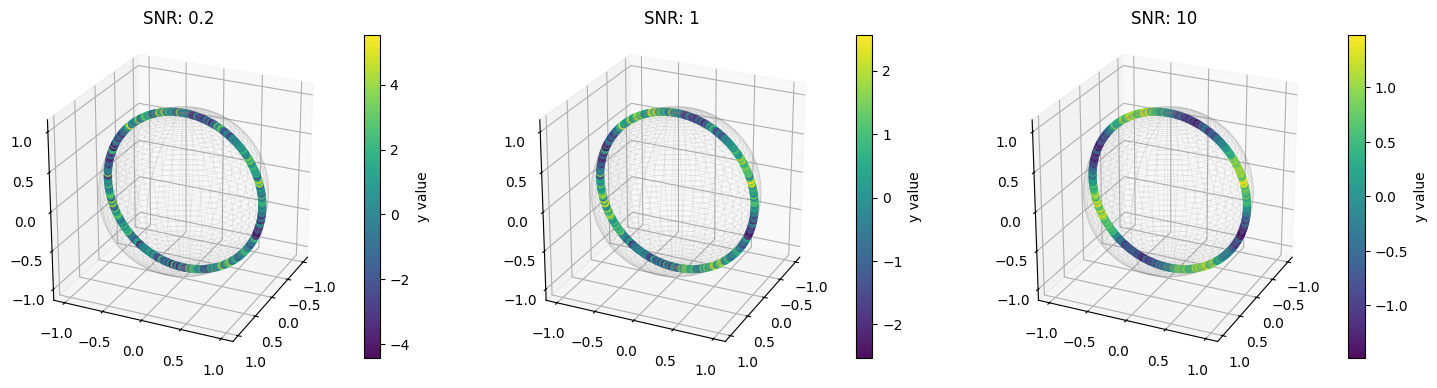

In [12]:
"""
Returns per-task MSEs on TWO independent test replicates (A,B),
plus seed-level aggregates for baseline repeatability and model-baseline gap.

Baseline repeatability is estimated by comparing baseline MSE on test A vs test B.
Model-baseline gap is |MSE_model - MSE_base| / MSE_base on replicate A (and also B).
"""

        

def plot_great_circles_3d(X, y, task_slices, elev=25, azim=25, cmap="viridis", title='', ax=None):

    """
    Plot training data of different-circle harmonics on the sphere
    """
    if ax is None:
        fig = plt.figure(figsize=(6,6))
        ax = fig.add_subplot(111, projection='3d')
    else:
        fig = ax.figure

    # Plot circles (save the last scatter handle)
    sc = None
    for sl in task_slices:
        sc = ax.scatter(X[sl,0], X[sl,1], X[sl,2],
                        c=y[sl], cmap=cmap,
                        s=25, alpha=0.95)

    # Sphere grid
    u = np.linspace(0, 2*np.pi, 50)
    v = np.linspace(0, np.pi, 50)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))
    ax.plot_wireframe(xs, ys, zs, color='gray', alpha=0.15, linewidth=0.5)

    ax.set_title(title)
    ax.view_init(elev=elev, azim=azim)
    ax.set_box_aspect((1,1,1))

    # Add colorbar (using last scatter)
    cbar = fig.colorbar(sc, ax=ax, shrink=0.7)
    cbar.set_label("y value")

    return fig, ax

example_snrs = [0.2, 1, 10]
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6),
    subplot_kw={"projection": "3d"},
)
for i, snr in enumerate(example_snrs):
    seed =100
    test_pts_per_circle = None
    normals_mode = 'fibonacci'
    K_tasks = 1
    random_phase = False
    generalization = 'within'
    noise_std=None
    snr = snr
    noise_on = 'both'
    pts_per_circle = 256
    m=4

    rng = np.random.default_rng(seed)
    if test_pts_per_circle is None:
        test_pts_per_circle = 2 * pts_per_circle

    def sample_tasks(rng_local):
        if normals_mode == "random":
            normals = sample_random_normals_s2(K_tasks, rng=rng_local)
        elif normals_mode == "fibonacci":
            normals = normals_fibonacci_s2(K_tasks)
        else:
            raise ValueError("normals_mode must be 'random' or 'fibonacci'")
        phases = rng_local.uniform(0, 2*np.pi, size=K_tasks) if random_phase else np.zeros(K_tasks)
        return normals, phases

    normals_tr, phases_tr = sample_tasks(rng)

    if generalization == "within":
        normals_te, phases_te = normals_tr, phases_tr
    elif generalization == "across":
        normals_te, phases_te = sample_tasks(rng)
    else:
        raise ValueError("generalization must be 'within' or 'across'")

    # ----------------------------
    # Train set: grid sampling
    # ----------------------------
    X_train_np, y_train_np, task_slices_train = generate_multi_tasks_from_normals_phases_with_mode(
        normals_tr, phases_tr, pts_per_circle=pts_per_circle, m=m, rng=rng, mode="grid"
    )

    # ----------------------------
    # Test replicate A/B: independent random sampling of phi
    # ----------------------------
    rngA = np.random.default_rng(seed + 10_000_001)

    X_testA_np, y_testA_np, task_slices_testA = generate_multi_tasks_from_normals_phases_with_mode(
        normals_te, phases_te, pts_per_circle=test_pts_per_circle, m=m, rng=rngA, mode="random"
    )

    # ----------------------------
    # Optional: additive Gaussian label noise (SNR control)
    # ----------------------------
    # Signal variance for sin(m phi) is ~ 1/2 (exact for uniform phi).
    # We estimate it empirically on the *noise-free* training labels.
    if noise_std is None and snr is not None:
        sig_var = float(np.var(y_train_np))  # empirical
        noise_var = sig_var / float(snr)
        noise_std = float(np.sqrt(max(noise_var, 0.0)))

    if noise_std is not None and noise_std > 0:
        rngN = np.random.default_rng(seed + 20_000_000)

        if noise_on in ("train", "both"):
            y_train_np = y_train_np + rngN.normal(0.0, noise_std, size=y_train_np.shape)

        if noise_on in ("test", "both"):
            # independent noise stream for test
            rngNt = np.random.default_rng(seed + 30_000_000)
            y_testA_np = y_testA_np + rngNt.normal(0.0, noise_std, size=y_testA_np.shape)
            
    plot_great_circles_3d(X_train_np, y_train_np, task_slices_train, elev=25, azim=25, cmap="viridis", title=f"SNR: {snr}", ax=axes[i])


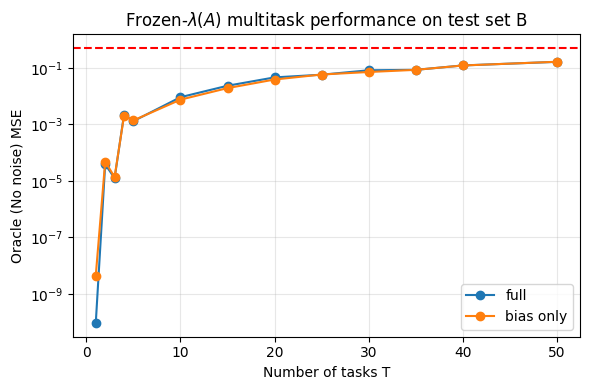

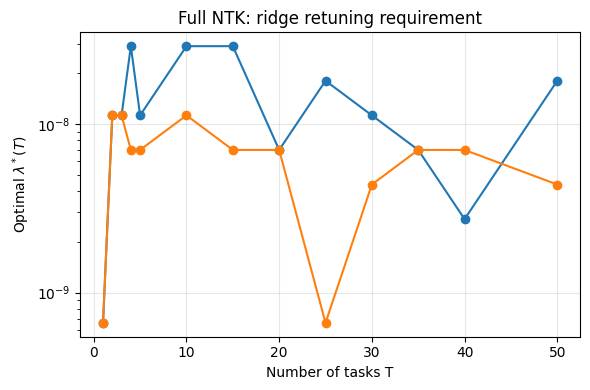

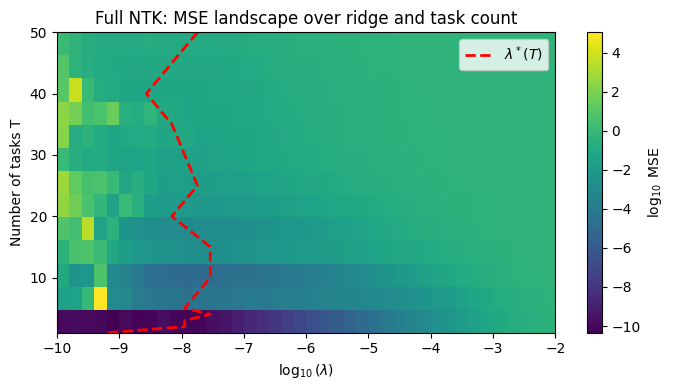

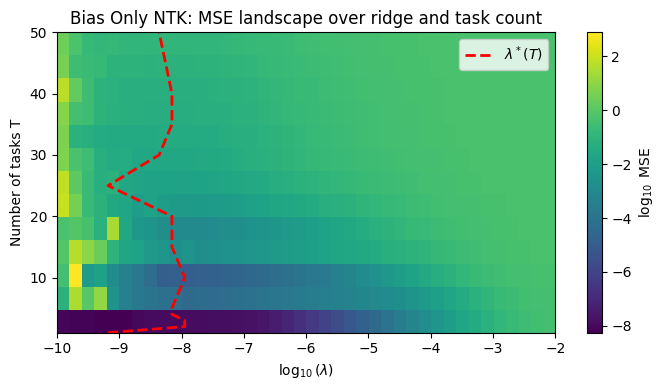

In [3]:
import numpy as np
addn_str = "cntrl_tot_pts_out_bias_valset"

# Load tuned lambdas from the A-side tuning file
D_ridge = np.load(
    f"/home/dburnham/Documents/NTK/neural-tangents/multiTasking/results/"
    f"ridge_tuning_results/ridge_tuning_by_T_{addn_str}.npz"
)

# Load frozen evaluation on independent B
D_eval = np.load(
    f"/home/dburnham/Documents/NTK/neural-tangents/multiTasking/results/"
    f"ridge_eval_results/frozen_ridge_eval_by_T_{addn_str}.npz",
    allow_pickle=True,
)

T_list = D_ridge["T_list"]
reg_list = D_ridge["reg_list"]
mse_grid_full = D_ridge["mse_grid_full_ntk"]
mse_star_full = D_ridge["mse_star_full_ntk"]
lam_star_full = D_ridge["lam_star_full_ntk"]
mse_grid_bias = D_ridge["mse_grid_bias_only"]
mse_star_bias = D_ridge["mse_star_bias_only"]
lam_star_bias = D_ridge["lam_star_bias_only"]

full_res = D_eval["full_ntk"].item()
bias_res = D_eval["bias_only"].item()

mse_star_full = np.asarray(full_res["mse_mean_B"], dtype=float)
mse_star_bias = np.asarray(bias_res["mse_mean_B"], dtype=float)

plt.figure(figsize=(6, 4))
plt.plot(T_list, mse_star_full, marker="o", label="full")
plt.plot(T_list, mse_star_bias, marker="o", label="bias only")
plt.axhline(0.5, linestyle="--", color="r")
plt.yscale("log")
plt.xlabel("Number of tasks T")
plt.ylabel("Oracle (No noise) MSE")
plt.title(r"Frozen-$\lambda(A)$ multitask performance on test set B")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.semilogy(T_list, lam_star_full, marker="o", label='full')
plt.semilogy(T_list, lam_star_bias, marker="o", label='bias only')
plt.xlabel("Number of tasks T")
plt.ylabel(r"Optimal $\lambda^*(T)$")
plt.title("Full NTK: ridge retuning requirement")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))

# log10 MSE for better contrast
Z = np.log10(mse_grid_full)

im = plt.imshow(
    Z,
    aspect="auto",
    origin="lower",
    extent=[
        np.log10(reg_list[0]),
        np.log10(reg_list[-1]),
        T_list[0],
        T_list[-1],
    ],
    cmap="viridis",
)

plt.colorbar(im, label=r"$\log_{10}$ MSE")
plt.plot(np.log10(lam_star_full), T_list, "r--", lw=2, label=r"$\lambda^*(T)$")

plt.xlabel(r"$\log_{10}(\lambda)$")
plt.ylabel("Number of tasks T")
plt.title("Full NTK: MSE landscape over ridge and task count")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))

# log10 MSE for better contrast
Z = np.log10(mse_grid_bias)

im = plt.imshow(
    Z,
    aspect="auto",
    origin="lower",
    extent=[
        np.log10(reg_list[0]),
        np.log10(reg_list[-1]),
        T_list[0],
        T_list[-1],
    ],
    cmap="viridis",
)

plt.colorbar(im, label=r"$\log_{10}$ MSE")
plt.plot(np.log10(lam_star_bias), T_list, "r--", lw=2, label=r"$\lambda^*(T)$")
plt.xlabel(r"$\log_{10}(\lambda)$")
plt.ylabel("Number of tasks T")
plt.title("Bias Only NTK: MSE landscape over ridge and task count")
plt.legend()
plt.tight_layout()
plt.show()

Kernel: full_ntk


/tmp/ipykernel_148345/3543382421.py:172: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])


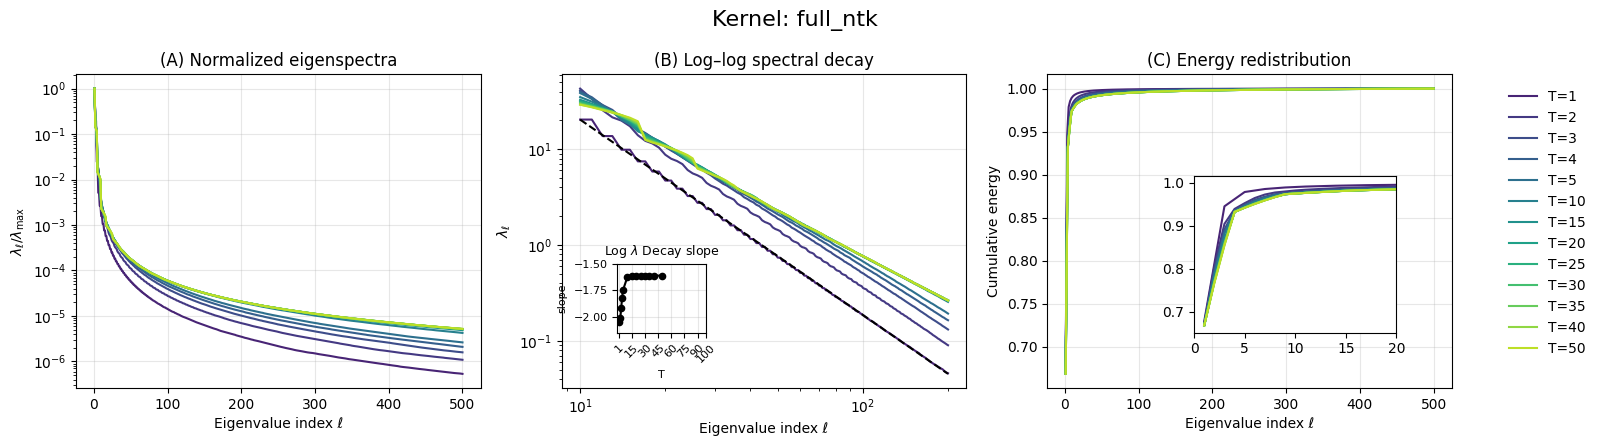

Kernel: bias_only


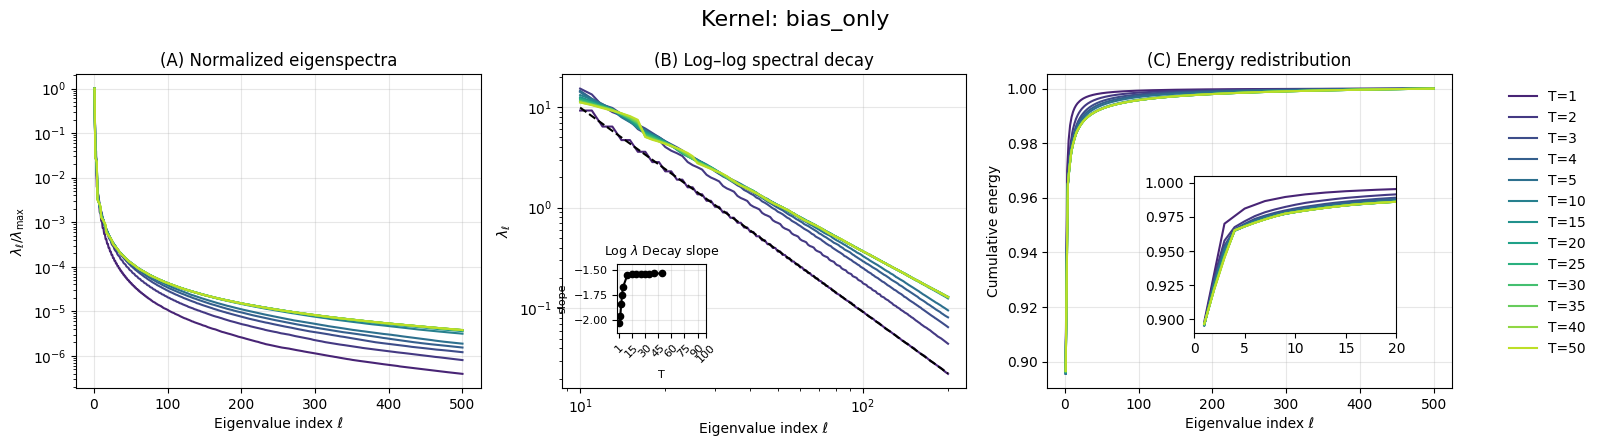

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def plot_spectral_diagnostics(
    eigvals_by_T: dict[int, np.ndarray],
    L_max: int | None = None,
    fit_range: tuple[int, int] = (5, 200),
    cmap: str = "viridis",
    sup_title: str | None = None,
):
    """
    Plots:
      (A) normalized eigenvalue spectra
      (B) log-log decay comparison
      (C) cumulative spectral energy

    Args:
      eigvals_by_T: dict[T -> eigenvalues]
      L_max: truncate spectrum to first L_max modes (largest eigenvalues)
      fit_range: (ell_min, ell_max) for slope diagnostics (visual only)
      cmap: matplotlib colormap
    """

    Ts = sorted(eigvals_by_T.keys())
    nT = len(Ts)
    colors = plt.get_cmap(cmap)(np.linspace(0.1, 0.9, nT))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # --------------------------------------------------
    # (A) Normalized spectra: lambda_l / lambda_max
    # --------------------------------------------------
    ax = axes[0]
    for T, c in zip(Ts, colors):
        lam = np.asarray(eigvals_by_T[T], dtype=float)

        # sort descending
        lam = np.sort(lam)[::-1]
        if L_max is not None:
            lam = lam[:L_max]

        lam_norm = lam / np.max(lam)
        ell = np.arange(1, len(lam_norm) + 1)

        ax.plot(ell, lam_norm, color=c, label=f"T={T}")

    ax.set_yscale("log")
    ax.set_xlabel("Eigenvalue index ℓ")
    ax.set_ylabel(r"$\lambda_\ell / \lambda_{\max}$")
    ax.set_title("(A) Normalized eigenspectra")
    ax.grid(True, alpha=0.3)

    # --------------------------------------------------
    # (B) Log–log decay comparison
    # --------------------------------------------------
    ax = axes[1]
    slopes = []
    for T, c in zip(Ts, colors):
        lam = np.asarray(eigvals_by_T[T], dtype=float)
        lam = np.sort(lam)[::-1]
        if L_max is not None:
            lam = lam[:L_max]

        ell = np.arange(1, len(lam) + 1)

        mask = (ell >= fit_range[0]) & (ell <= fit_range[1]) & (lam > 0)
        ax.plot(ell[mask], lam[mask], color=c, label=f"T={T}")
        #estimate log-log slope
        log_ell = np.log(ell[mask])
        log_lam = np.log(lam[mask])
        slope, intercept = np.polyfit(log_ell, log_lam, 1)
        slopes.append(slope)
        #if plotting first T, have example black log-log line
        if T == Ts[0]:
            ell_line = np.array(fit_range)
            lam_line = np.exp(intercept) * ell_line ** slope
            ax.plot(
                ell_line,
                lam_line,
                color="black",
                linestyle="--",
                linewidth=1.5,
                label=f"slope={slope:.2f}",
            )
    
    ax_in = inset_axes(
            ax,
            width="22%",     # fraction of parent axis
            height="22%",
            loc="lower left",
            borderpad=4.
        )
    T_arr = np.asarray(Ts)
    ax_in.plot(
                T_arr,
                slopes,
                marker="o",
                linestyle="-",
                linewidth=1.5,
                markersize=4.5,
                color="k",
            )
    ax_in.set_title(r"Log $\lambda$ Decay slope", fontsize=9)
    ax_in.set_xlabel("T", fontsize=8)
    ax_in.set_ylabel("slope", fontsize=8)

    # ax_in.tick_params(axis="both", which="major", labelsize=8)
    #set x tick labels to every 5 T
    tick_labels = np.array([1,15,30,45,60, 75, 90, 100])
    ax_in.set_xticks(tick_labels)
    #rotate x tick labels
    plt.setp(ax_in.get_xticklabels(), rotation=45, ha="center", fontsize=8)
    plt.setp(ax_in.get_yticklabels(), fontsize=8)

    ax_in.grid(True, alpha=0.3)

    # Optional: compress y-range to emphasize differences
    ax_in.set_ylim(
        np.min(slopes) - 0.1,
        np.max(slopes) + 0.1
    )
    #set the y ticks to have 3 ticks
    y_ticks = [-2.0, -1.75, -1.5]
    ax_in.set_yticks(y_ticks)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Eigenvalue index ℓ")
    ax.set_ylabel(r"$\lambda_\ell$")
    ax.set_title("(B) Log–log spectral decay")
    ax.grid(True, alpha=0.3)

    # --------------------------------------------------
    # (C) Cumulative spectral energy
    # --------------------------------------------------
    ax = axes[2]
    ax_in = inset_axes(
            ax,
            width="50%",     # fraction of parent axis
            height="50%",
            loc="lower right",
            borderpad=4.
        )
    
    for T, c in zip(Ts, colors):
        lam = np.asarray(eigvals_by_T[T], dtype=float)
        lam = np.sort(lam)[::-1]
        if L_max is not None:
            lam = lam[:L_max]

        cum_energy = np.cumsum(lam) / np.sum(lam)
        ell = np.arange(1, len(cum_energy) + 1)

        ax.plot(ell, cum_energy, color=c, label=f"T={T}")
        ax_in.plot(ell, cum_energy, color=c)
    ax_in.set_xlim(0, 20)
    ax.set_xlabel("Eigenvalue index ℓ")
    ax.set_ylabel("Cumulative energy")
    # ax.set_ylim(0, 1.02)
    ax.set_title("(C) Energy redistribution")
    ax.grid(True, alpha=0.3)

    # --------------------------------------------------
    # Legend
    # --------------------------------------------------
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center right", frameon=False)
    #add suptitle
    if sup_title != '' or sup_title is not None:
        plt.suptitle(sup_title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.92, 1])
    plt.show()

# D = np.load(f"/home/dburnham/Documents/NTK/neural-tangents/multiTasking/results/eigen_spectra_results/eigen_spectra_by_T_eigen_spectra_multitask.npz", allow_pickle=True)
D = np.load(f"/home/dburnham/Documents/NTK/neural-tangents/multiTasking/results/eigen_spectra_results/eigen_spectra_by_T_eigen_spectra_multitask_cntrl_tot_pts_out_bias.npz", allow_pickle=True)
for kernel_key in D.keys():
    print(f"Kernel: {kernel_key}")
    eig_dict = {}
    results = D[kernel_key].item()
    T_list = results["T_list"]
    eigvals = results["eigvals"] #shape (len(T_list), num_seeds, num_eigvals)
    #if number of seeds > 1, average over seeds
    if eigvals.shape[1] > 1:
        eigvals = np.mean(eigvals, axis=1) #shape (len(T_list), num_eigvals)
    else:
        eigvals = eigvals[:,0,:] #shape (len(T_list), num_eigvals)
    for i, T in enumerate(T_list):
        eigsT = eigvals[i]
        #check for trailing nan values and remove
        eigsT = eigsT[~np.isnan(eigsT)]
        eig_dict[int(T)] = eigsT
        
    plot_spectral_diagnostics(
        eigvals_by_T=eig_dict,
        L_max=500,          # optional
        fit_range=(10, 200),
        sup_title=f"Kernel: {kernel_key}"
    )
    

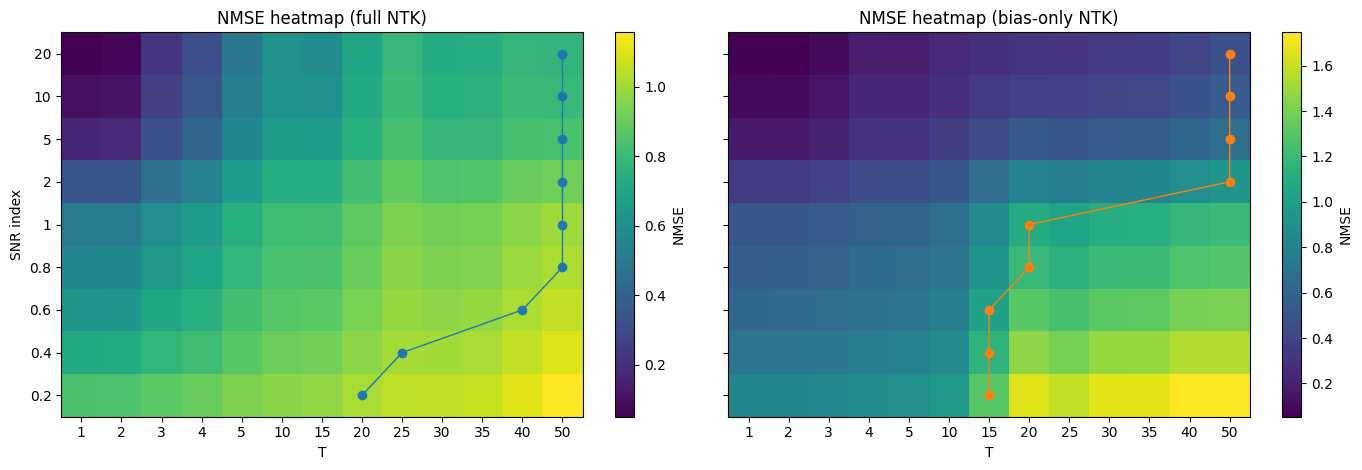

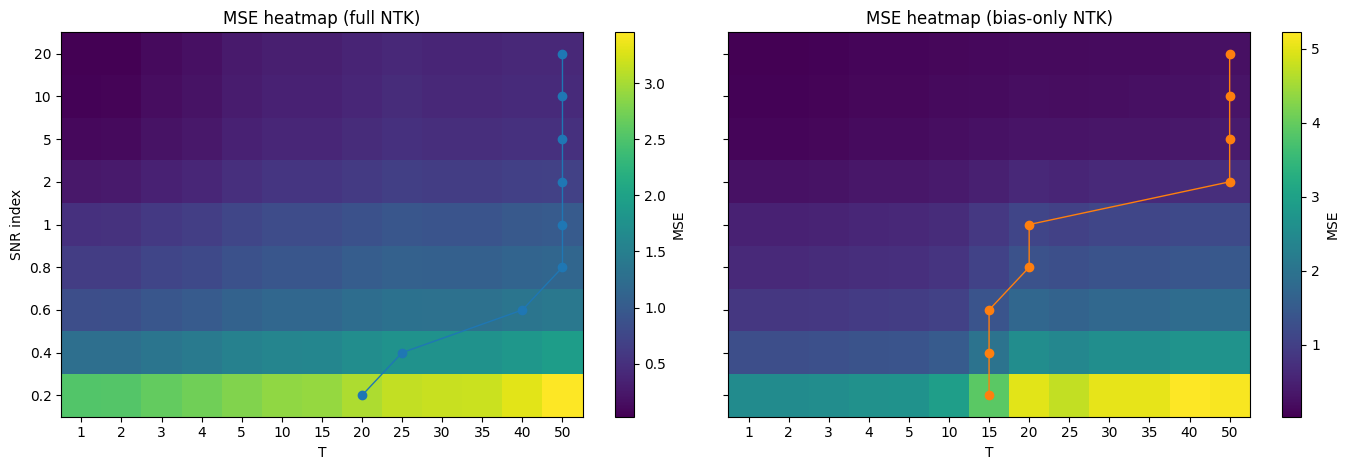

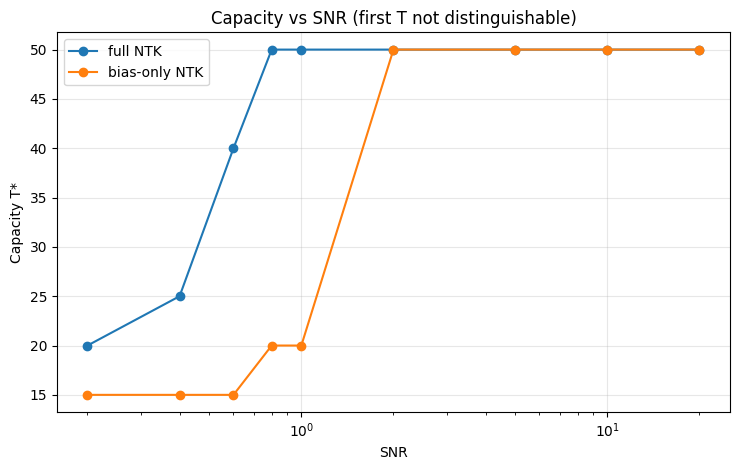

{'snr_list': array([ 0.2,  0.4,  0.6,  0.8,  1. ,  2. ,  5. , 10. , 20. ]),
 'T_list': array([ 1,  2,  3,  4,  5, 10, 15, 20, 25, 30, 35, 40, 50]),
 'reg_list_placeholder': array([], dtype=float64),
 'nmse_full': array([[0.83859862, 0.8437969 , 0.87584957, 0.90047623, 0.9373005 ,
         0.96083731, 0.97313713, 1.00949781, 1.04676324, 1.05194502,
         1.06043275, 1.10101859, 1.15617917],
        [0.71920262, 0.72563401, 0.77630213, 0.81240325, 0.87010315,
         0.90621054, 0.91640094, 0.96406953, 1.00905889, 1.00355151,
         1.01185284, 1.05268233, 1.09879547],
        [0.62972214, 0.63697656, 0.70167704, 0.74630199, 0.81964117,
         0.86548345, 0.87367008, 0.92976303, 0.98047014, 0.96727045,
         0.97533707, 1.01643042, 1.05566191],
        [0.56014453, 0.56801169, 0.64364986, 0.69486708, 0.7803736 ,
         0.83391009, 0.8403551 , 0.90297469, 0.95809342, 0.93905207,
         0.9469011 , 0.9882019 , 1.02201112],
        [0.50448738, 0.51283847, 0.59723538, 0.65370

In [13]:
def load_snr_sweep_npz(path: str) -> dict:
    """Load the .npz produced by run_snr_sweep_and_save into a plain dict."""
    D = np.load(path, allow_pickle=True)
    out = {k: D[k] for k in D.files}
    D.close()
    return out


def plot_snr_sweep_results(
    path: str,
    metric: str = "nmse",          # "nmse" or "mse"
    kind: str = "heatmap",         # "heatmap" or "curves"
    which: str = "full",           # "full" or "bias" (for curves)
    log_y: bool = True,            # for curves with MSE
    show: bool = True,
):
    """
    Plots results saved by run_snr_sweep_and_save.

    Saved arrays (expected):
      nmse_full, nmse_bias, mse_full, mse_bias  shape (n_snr, n_T)
      cap_full_last_sig, cap_bias_last_sig      shape (n_snr,)
      snr_list shape (n_snr,), T_list shape (n_T,)
    """
    R = load_snr_sweep_npz(path)

    snr = np.asarray(R["snr_list"], dtype=float)
    T = np.asarray(R["T_list"], dtype=int)

    if metric not in ("nmse", "mse"):
        raise ValueError("metric must be 'nmse' or 'mse'")

    A_full = np.asarray(R[f"{metric}_full"], dtype=float)
    A_bias = np.asarray(R[f"{metric}_bias"], dtype=float)

    cap_full = np.asarray(R.get("cap_full_first_not_sig", np.full_like(snr, T[-1])), dtype=int)
    cap_bias = np.asarray(R.get("cap_bias_first_not_sig", np.full_like(snr, T[-1])), dtype=int)

    if kind == "heatmap":
        fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)

        # x-axis: T index (discrete), y-axis: SNR (log scaled)
        x = np.arange(len(T) + 1) - 0.5  # bin edges for pcolormesh
        y = np.arange(len(snr) + 1) - 0.5

        im0 = axes[0].pcolormesh(x, y, A_full, shading="auto")
        axes[0].set_title(f"{metric.upper()} heatmap (full NTK)")
        axes[0].set_xlabel("T")
        axes[0].set_ylabel("SNR index")
        cb0 = fig.colorbar(im0, ax=axes[0])
        cb0.set_label(metric.upper())

        im1 = axes[1].pcolormesh(x, y, A_bias, shading="auto")
        axes[1].set_title(f"{metric.upper()} heatmap (bias-only NTK)")
        axes[1].set_xlabel("T")
        cb1 = fig.colorbar(im1, ax=axes[1])
        cb1.set_label(metric.upper())

        # T tick labels
        xt = np.arange(len(T))
        for ax in axes:
            ax.set_xticks(xt)
            ax.set_xticklabels(T, rotation=0)
            ax.set_yticks(np.arange(len(snr)))
            ax.set_yticklabels([f"{v:g}" for v in snr])

        # Overlay capacity curves (convert T value -> index)
        def t_to_idx(cap_arr):
            idx = np.array([np.where(T == c)[0][0] if c in T else np.argmin(np.abs(T - c)) for c in cap_arr])
            return idx

        axes[0].plot(t_to_idx(cap_full), np.arange(len(snr)), marker="o", linestyle="-", linewidth=1, color='tab:blue')
        axes[1].plot(t_to_idx(cap_bias), np.arange(len(snr)), marker="o", linestyle="-", linewidth=1, color='tab:orange')

        plt.tight_layout()

    elif kind == "curves":
        fig, ax = plt.subplots(1, 1, figsize=(7.5, 4.8))

        if which == "full":
            A = A_full
            cap = cap_full
            label0 = "full NTK"
        elif which == "bias":
            A = A_bias
            cap = cap_bias
            label0 = "bias-only NTK"
        else:
            raise ValueError("which must be 'full' or 'bias'")

        # Plot a few representative SNR slices
        # Choose ~6 evenly spaced indices
        n_show = min(6, len(snr))
        idxs = np.linspace(0, len(snr) - 1, n_show).astype(int)

        for j in idxs:
            ax.plot(T, A[j, :], marker="o", linewidth=1, label=f"SNR={snr[j]:g}")

        ax.set_title(f"{metric.upper()} vs T ({label0})")
        ax.set_xlabel("Number of tasks T")
        ax.set_ylabel(metric.upper())

        if metric == "mse" and log_y:
            ax.set_yscale("log")

        ax.grid(True, alpha=0.3)
        ax.legend()

        # Capacity vs SNR on a twin axis (optional)
        ax2 = ax.twinx()
        ax2.plot(T, np.zeros_like(T), alpha=0.0)  # keep axis alive

        plt.tight_layout()
    else:
        raise ValueError("kind must be 'heatmap' or 'curves'")

    if show:
        plt.show()

    return R


def plot_capacity_vs_snr(path: str, use: str = "last_sig", show: bool = True):
    """
    Plot capacity (T*) vs SNR for both kernels.
    use: "last_sig" or "first_not_sig"
    """
    R = load_snr_sweep_npz(path)
    snr = np.asarray(R["snr_list"], dtype=float)

    if use == "last_sig":
        cap_full = np.asarray(R["cap_full_last_sig"], dtype=int)
        cap_bias = np.asarray(R["cap_bias_last_sig"], dtype=int)
        title = "Capacity vs SNR (largest T still distinguishable)"
    elif use == "first_not_sig":
        cap_full = np.asarray(R["cap_full_first_not_sig"], dtype=int)
        cap_bias = np.asarray(R["cap_bias_first_not_sig"], dtype=int)
        title = "Capacity vs SNR (first T not distinguishable)"
    else:
        raise ValueError("use must be 'last_sig' or 'first_not_sig'")
    
    fig, ax = plt.subplots(1, 1, figsize=(7.5, 4.8))
    ax.plot(snr, cap_full, marker="o", label="full NTK")
    ax.plot(snr, cap_bias, marker="o", label="bias-only NTK")
    ax.set_xscale("log")
    ax.set_xlabel("SNR")
    ax.set_ylabel("Capacity T*")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()

    if show:
        plt.show()

    return R

addn_str = "cntrl_tot_pts_out_bias"
path = f"/home/dburnham/Documents/NTK/neural-tangents/multiTasking/results/snr_sweep_results/snr_sweep_by_T_{addn_str}.npz"  # change to your output file

# 1) Heatmaps of NMSE for full vs bias, with capacity overlay
plot_snr_sweep_results(path, metric="nmse", kind="heatmap")

# 2) Heatmaps of MSE
plot_snr_sweep_results(path, metric="mse", kind="heatmap")

# 3) Capacity vs SNR curve
plot_capacity_vs_snr(path, use="first_not_sig")
